In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *

sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

# Importeren van de database

In [2]:
# Read into a pandas DataFrame
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data','database_all_v5.sqlite')))
df_final = load_and_merge_data(working_dir.parent.joinpath('data','database_all_v5.sqlite'))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)



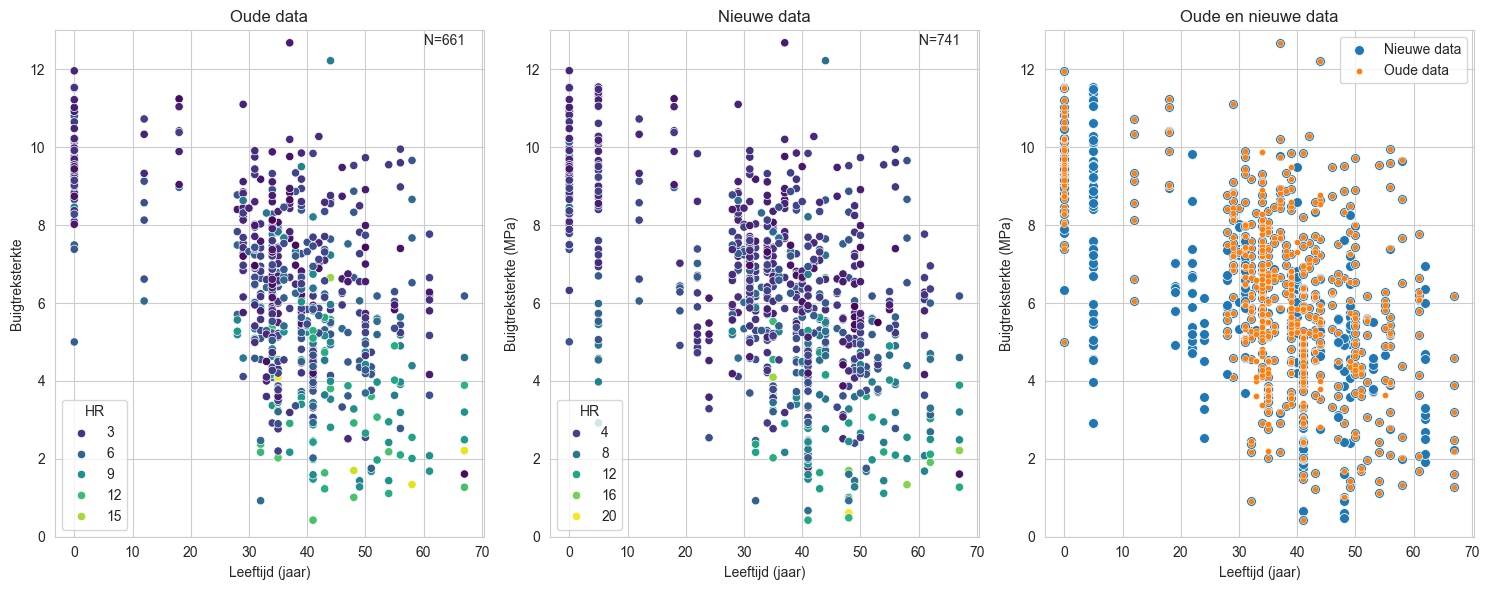

In [3]:
#load the old dataset
df_old = pd.read_excel(r"c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\Database WAB - overzicht ADL28062023_BWich_selection18.8.xlsx")

fig,ax = plt.subplots(ncols=3, figsize=(15,6))
sns.scatterplot(data=df_old, x = 'leeftijd', y = 'Buigtreksterkte',hue='HR', ax=ax[0],palette='viridis')
sns.scatterplot(data=df_final, x = 'age_at_investigation', y = 'sig_b', hue='HR', ax=ax[1],palette='viridis')
sns.scatterplot(data=df_final, x = 'age_at_investigation', y = 'sig_b', ax=ax[2],s=50,label='Nieuwe data')
sns.scatterplot(data=df_old, x = 'leeftijd', y = 'Buigtreksterkte', ax=ax[2],s=20, label='Oude data')
ax[0].set_title('Oude data')
ax[1].set_title('Nieuwe data')
ax[2].set_title('Oude en nieuwe data')
ax[1].set_ylabel('Buigtreksterkte (MPa)')
ax[2].set_ylabel('Buigtreksterkte (MPa)')
ax[0].set_xlabel('Leeftijd (jaar)')
ax[1].set_xlabel('Leeftijd (jaar)')
ax[2].set_xlabel('Leeftijd (jaar)')
ax[0].set_ylim(0,13)
ax[1].set_ylim(0,13)
ax[2].set_ylim(0,13)
#aantal punten met buigtreksterkte in beide dataframes:
ax[0].text(60, 12.9, f"N={df_old['Buigtreksterkte'].dropna().shape[0]}",verticalalignment='top')
ax[1].text(60, 12.9, f"N={df_final['sig_b'].dropna().shape[0]}",verticalalignment='top')
ax[2].legend()
plt.tight_layout()

Text(65, -2, 'Met fasehoek = 436 boorkernen')

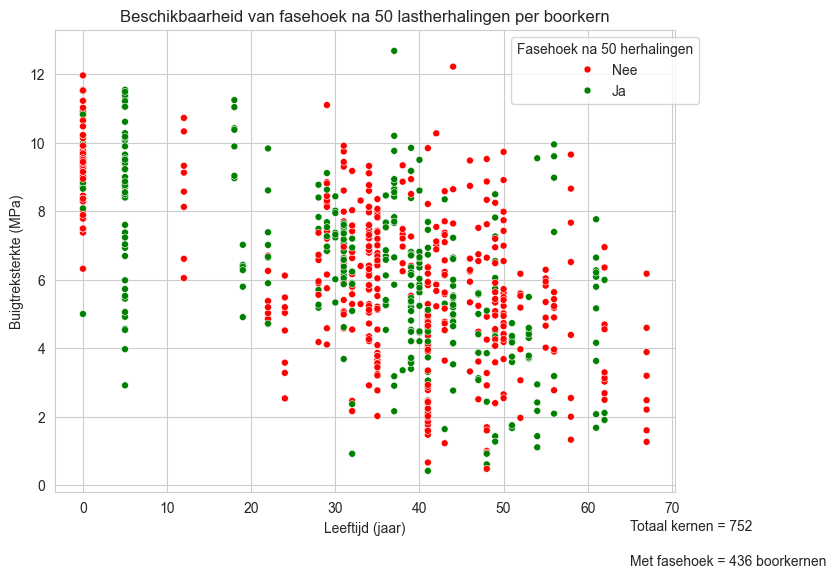

In [4]:
#make a graph highlighting for all boreholes whether pha_50 is nan or not
fig,ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_final, x = 'age_at_investigation', y = 'sig_b', hue=df_final['pha_50'].isna(), palette={True: 'green', False: 'red'}, s=25)
ax.set_title('Beschikbaarheid van fasehoek na 50 lastherhalingen per boorkern')
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_xlabel('Leeftijd (jaar)')
#get legend handles
h, l = ax.get_legend_handles_labels()
#replace labels with meaningful text
l = ['Nee', 'Ja']
ax.legend(h, l, title='Fasehoek na 50 herhalingen', bbox_to_anchor=(1.05, 1))
#add in text the number of boreholes with a value for pha_50. add it to the legend

ax.text(65, -1, f"Totaal kernen = {df_final['pha_50'].shape[0]}", verticalalignment='top',horizontalalignment='left')
ax.text(65, -2, f"Met fasehoek = {df_final['pha_50'].dropna().shape[0]} boorkernen", verticalalignment='top',horizontalalignment='left')

In [5]:
#count df_final.v <0.3
count_v_below_03 = df_final.loc[df_final['v'] < 0.3].shape[0]
print(f"Aantal boorkernen met verplaatsing < 0.3 mm: {count_v_below_03}")
#count age_at_investigation > 50
count_age_above_50 = df_final.loc[df_final['age_at_investigation'] > 50].shape[0]
print(f"Aantal boorkernen met leeftijd > 50 jaar: {count_age_above_50}")

#aantal unieke projecten met age_at_investigation > 50
unique_projects_above_50 = df_final.loc[df_final['age_at_investigation'] > 50]['project_dike_id'].nunique()
print(f"Aantal unieke dijkprojecten met leeftijd > 50 jaar: {unique_projects_above_50}")


Aantal boorkernen met verplaatsing < 0.3 mm: 9
Aantal boorkernen met leeftijd > 50 jaar: 96
Aantal unieke dijkprojecten met leeftijd > 50 jaar: 12


In [6]:
df_final_original = df_final.copy()
data_per_dike_project_original = data_per_dike_project.copy()
#filter the data op v < 0.3 en age_at_investigation > 50
df_final = df_final.loc[(df_final['v'] >= 0.3)]
df_final = df_final.loc[(df_final['age_at_investigation'] <= 50)]

#remake df for sections
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)



In [7]:
#Export voor regressie
data_for_regression = df_final[['borehole_id','age_at_investigation', 'sig_b', 'HR']]
#rename sig_b to str and age_at_investigation to age and HR to void
data_for_regression = data_for_regression.rename(columns={'sig_b':'str', 'age_at_investigation':'age', 'HR':'void'})
#export to xlsx
data_for_regression.to_excel(working_dir.joinpath('data_for_regression.xlsx'), index=False)
                               
    

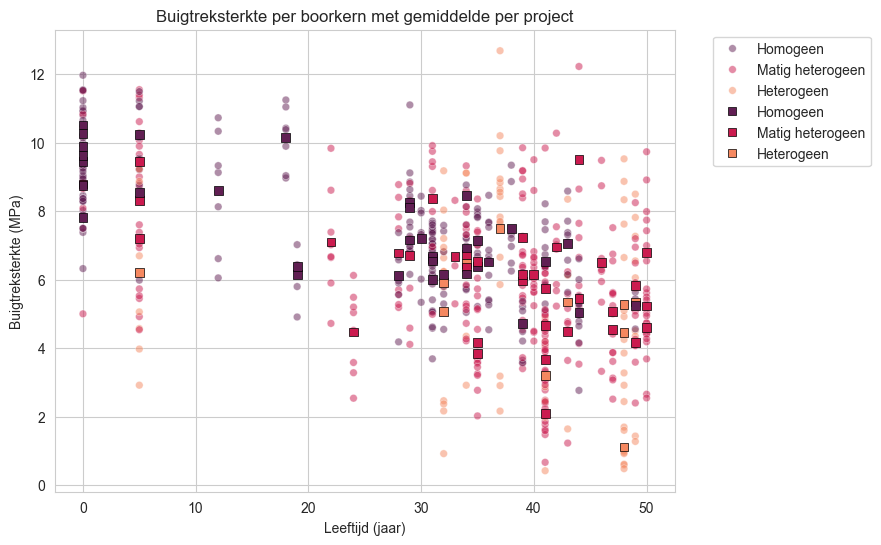

In [8]:
#plot boreholes with color for HR and add sig_b_mean per dike project
fig,ax = plt.subplots(figsize=(8,6))
hue_order = ['Homogeen', 'Matig heterogeen', 'Heterogeen']
sns.scatterplot(data=df_final, x = 'age_at_investigation', y = 'sig_b', hue='heterogeneity_category', palette='rocket', s=30, ax=ax, alpha= 0.5, hue_order=hue_order)
sns.scatterplot(data=data_per_dike_project, x = 'age_at_investigation', y = 'sig_b_mean', hue = 'heterogeneity_category', palette='rocket', s=40, edgecolor = 'k', marker = 's',ax=ax, hue_order=hue_order)
ax.set_title('Buigtreksterkte per boorkern met gemiddelde per project')
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_xlabel('Leeftijd (jaar)')
ax.legend(bbox_to_anchor=(1.05, 1))

#also plot std
# sns.scatterplot(data=data_per_dike_project, x = 'age_at_investigation', y = 'sig_b_std', color='green', s=25, marker = 's',ax=ax, label='Std dev boven gemiddelde')

## Maken van dataframe op projectniveau

## Toevoegen van extra classificaties
Bros/ductiel (V_ber)
Sterk/gemiddeld/zwak (sig_b)
Heterogeniteit (o.b.v sig_b_CoV)

<Axes: xlabel='V_Ber', ylabel='sig_b'>

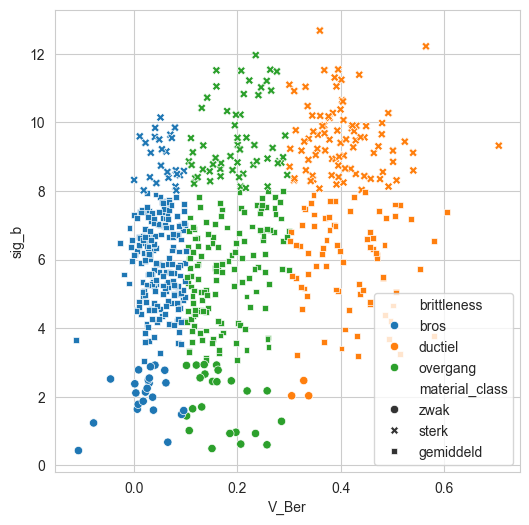

In [9]:

fig,ax = plt.subplots(figsize=(6, 6), ncols=1)
sns.scatterplot(data=df_final, x='V_Ber', y='sig_b', hue='brittleness',style='material_class', palette='tab10', ax=ax)


Text(0.5, 0, 'Leeftijd (jaar)')

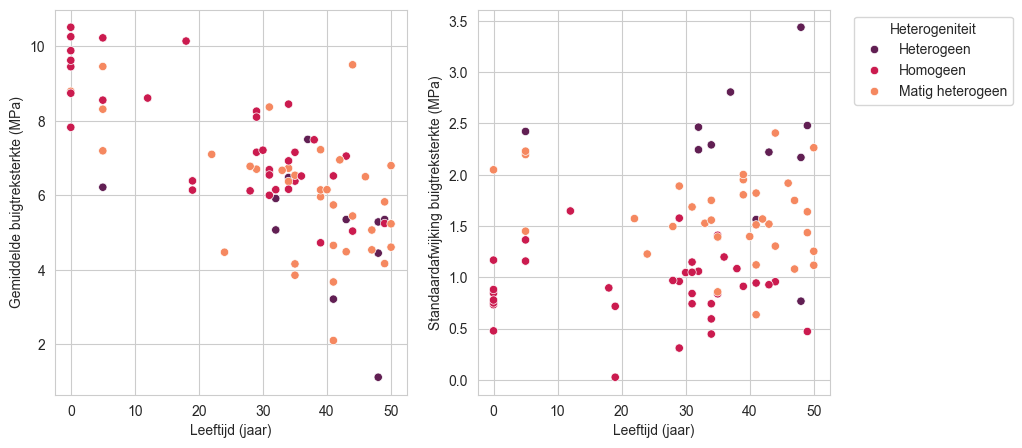

In [10]:
#scatterplot of age_at_investigation vs sig_b_mean, colored by heterogeneity_category
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', palette='rocket', ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_std', hue='heterogeneity_category', palette='rocket', ax=ax[1])

#remove legends but first get the handles and labels
h, l = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
ax[1].get_legend().remove()
#make new legend
ax[1].legend(h, l, title='Heterogeniteit', bbox_to_anchor=(1.05, 1))

ax[0].set_ylabel('Gemiddelde buigtreksterkte (MPa)')
ax[1].set_ylabel('Standaardafwijking buigtreksterkte (MPa)')
ax[0].set_xlabel('Leeftijd (jaar)')
ax[1].set_xlabel('Leeftijd (jaar)')



{'Lagrange multiplier statistic': np.float64(0.0336016682916318),
 'p-value': np.float64(0.8545566884613065),
 'f-value': np.float64(0.03336566045331878),
 'f p-value': np.float64(0.855195822877906)}

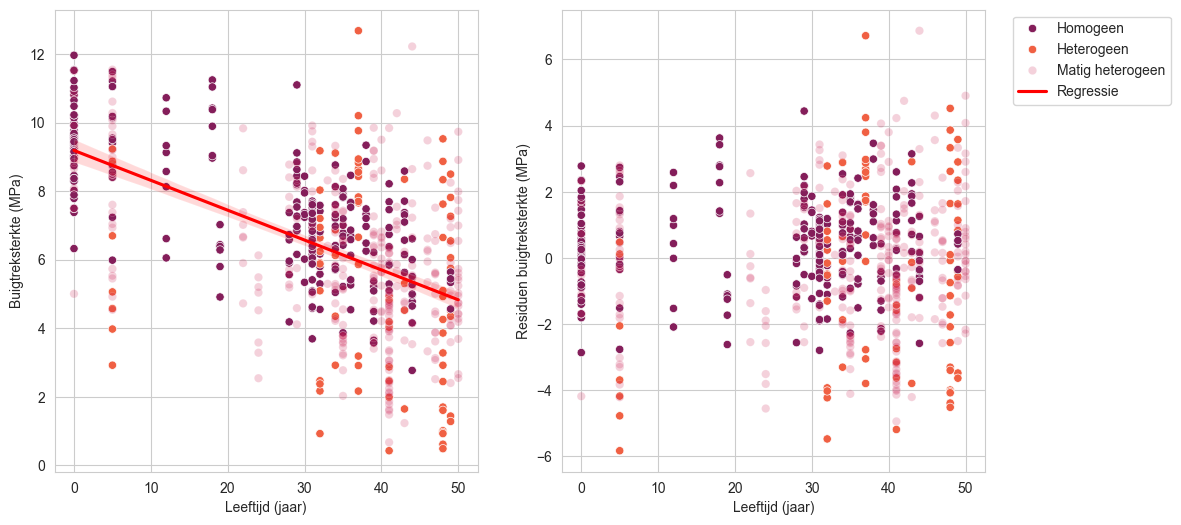

In [11]:
#do regression and get residuals of sig_b (from df_final)
from sklearn.linear_model import LinearRegression
from main.heterogeneity_regression import fit_linear_regression

df_final['target'] = df_final['sig_b']
regression_result = fit_linear_regression(df_final, heterogeneity_category='all', use_HR_as_regressor=False)
df_final['resid_all'] = regression_result['resid_all']
fig,ax = plt.subplots(ncols=2, figsize=(12,6))
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Matig heterogeen'], x='age_at_investigation', y='sig_b', hue='heterogeneity_category', hue_order=[hue_order[0], hue_order[2]], palette='rocket', ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] == 'Matig heterogeen'], x='age_at_investigation', y='sig_b', hue='heterogeneity_category', hue_order=[hue_order[1]], palette='rocket',alpha=0.2, ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Matig heterogeen'], x='age_at_investigation', y= 'resid_all', hue='heterogeneity_category', hue_order=[hue_order[0], hue_order[2]], palette='rocket', ax=ax[1                                                                                                                                                                                                                                                   ])
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] == 'Matig heterogeen'], x='age_at_investigation', y= 'resid_all', hue='heterogeneity_category', hue_order=[hue_order[1]], palette='rocket',alpha=0.2, ax=ax[1])

#add regplot in ax[0]
sns.regplot(data=df_final, x='age_at_investigation', y='sig_b', scatter=False, ax=ax[0], color = 'red', label = 'Regressie')

#remove legends but first get the handles and labels
h, l = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
ax[1].get_legend().remove()
#make new legend
ax[1].legend(h, l, bbox_to_anchor=(1.05, 1))

# sns.scatterplot(data=df_final, x = 'age_at_investigation', y = 'resid_all', hue = 'heterogeneity_category', palette='rocket', hue_order=hue_order, s=25)
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Residuen buigtreksterkte (MPa)')
ax[0].set_xlabel('Leeftijd (jaar)')
ax[1].set_xlabel('Leeftijd (jaar)')
df_final_test_heteroscedasticity = df_final.loc[(df_final["sig_b"]>0) & (~df_final["sig_b"].isna())]
pov_wadden_lijst = ['proefvakken_pov-wadden_-_vak_1_(harlingen)_-',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',]
#filterout POV Wadden
# df_final_test_heteroscedasticity = df_final_test_heteroscedasticity.loc[~df_final_test_heteroscedasticity.dike_name.isin(pov_wadden_lijst)]

#only homogeen
df_final_test_heteroscedasticity = df_final_test_heteroscedasticity.loc[df_final_test_heteroscedasticity['heterogeneity_category'] == 'Matig heterogeen']
#filterout matig heterogeen
# df_detrended_test = df_detrended.copy()
# df_detrended_test = df_detrended_test.loc[df_detrended_test['heterogeneity_category'] != 'Matig heterogeen']
#test for heteroscedasticity in detrended data
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
X = df_final_test_heteroscedasticity[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_final_test_heteroscedasticity['resid_all']
model = sm.OLS(y, X).fit()
residuals = model.resid
bp_test = het_breuschpagan(residuals, X)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
dict(zip(labels, bp_test)) 



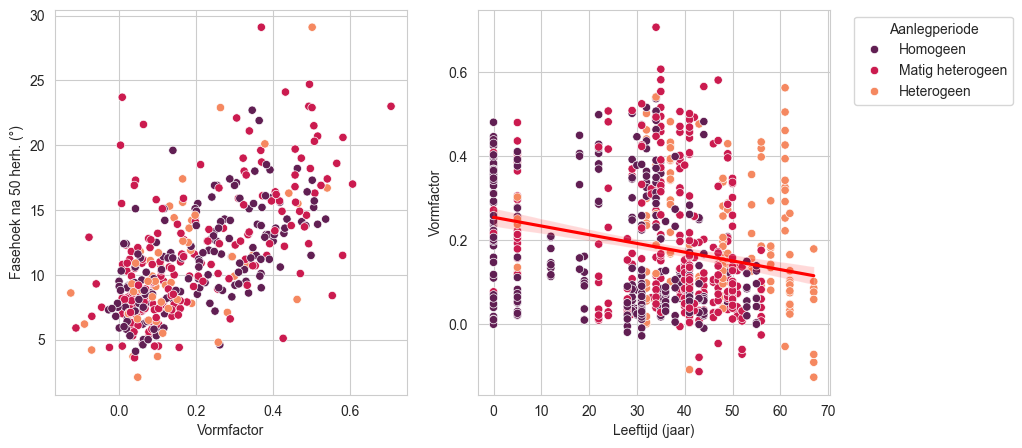

In [14]:
#correlation matrix for Homogeen
# df_final_copy = df_final_original.loc[df_final_original['heterogeneity_category'] == 'Homogeen'].copy()
df_final_copy = df_final_original.copy()
#plot scatterplot op pha_50 vs sig_b
parameter = 'V_Ber'
fig, ax = plt.subplots(figsize=(10,5),ncols=2)
sns.scatterplot(data=df_final_copy, x=parameter, y='pha_50', hue='heterogeneity_category', hue_order = hue_order, palette='rocket', ax=ax[0])
sns.scatterplot(data=df_final_copy, x='age_at_investigation', y=parameter, hue='heterogeneity_category', hue_order = hue_order, palette='rocket', ax=ax[1])
sns.regplot(data=df_final_copy, x='age_at_investigation', y=parameter, scatter=False, ax=ax[1], color = 'red', label = 'Regressie')
ax[0].set_xlabel('Vormfactor')
ax[0].set_ylabel('Fasehoek na 50 herh. (°)')
ax[1].set_xlabel('Leeftijd (jaar)')
ax[1].set_ylabel('Vormfactor')
#legend
h, l = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
ax[1].get_legend().remove()
#make new legend
ax[1].legend(h, l, title='Aanlegperiode', bbox_to_anchor=(1.05, 1))

<Axes: xlabel='age_at_investigation', ylabel='bitumen'>

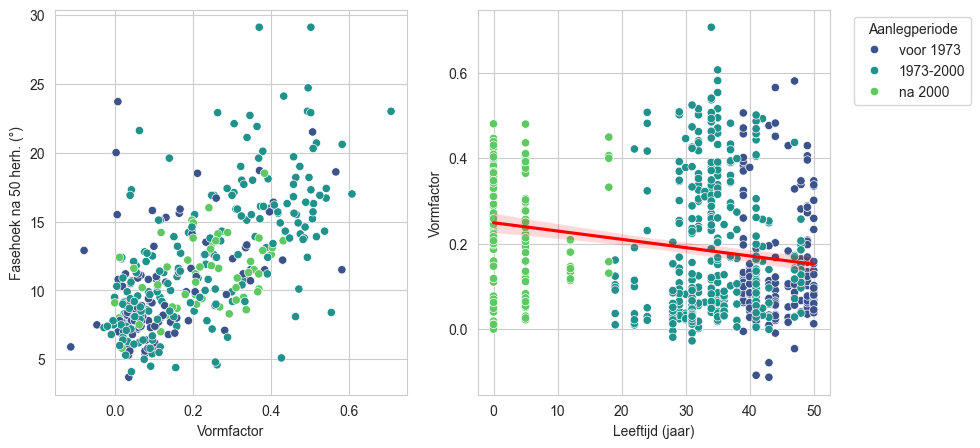

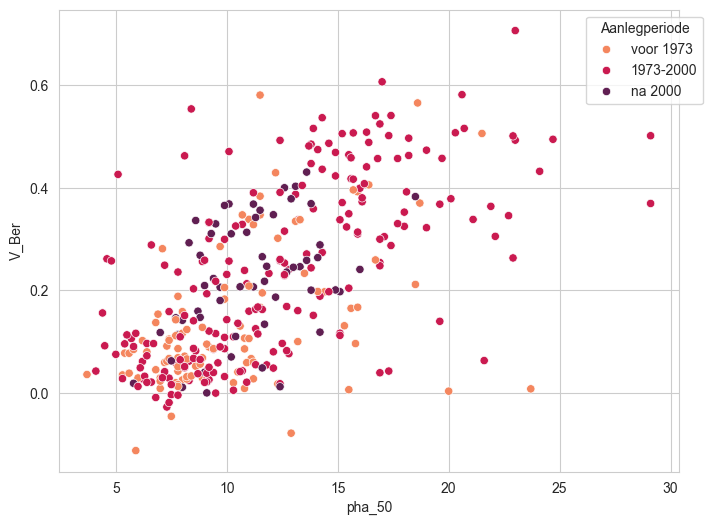

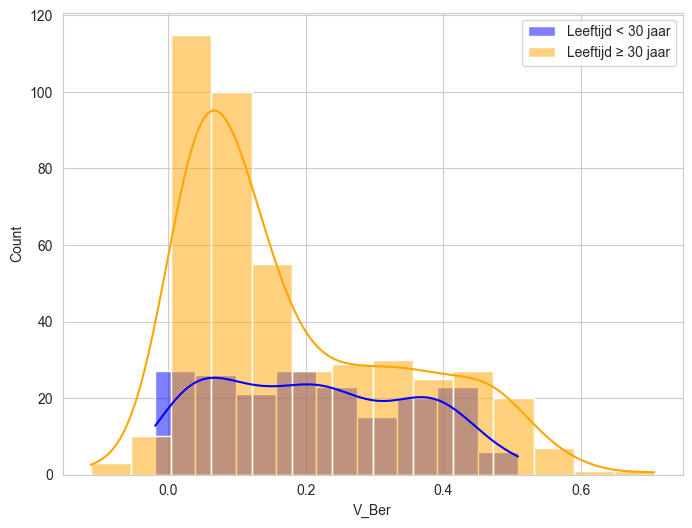

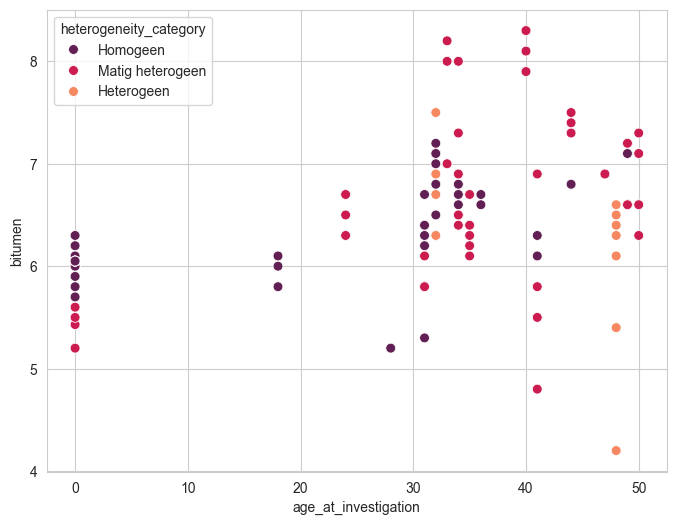

In [64]:
#correlation matrix for Homogeen
# df_final_copy = df_final_original.loc[df_final_original['heterogeneity_category'] == 'Homogeen'].copy()
df_final_copy = df_final_original.copy()
#plot scatterplot op pha_50 vs sig_b
parameter = 'V_Ber'
fig, ax = plt.subplots(figsize=(10,5),ncols=2)
sns.scatterplot(data=df_final_copy, x=parameter, y='pha_50', hue='construction_year_category', hue_order = ['voor 1973', '1973-2000', 'na 2000'], palette='viridis', ax=ax[0])
sns.scatterplot(data=df_final_copy, x='age_at_investigation', y=parameter, hue='construction_year_category', hue_order = ['voor 1973', '1973-2000', 'na 2000'], palette='viridis', ax=ax[1])
#regplot for ax[1]
sns.regplot(data=df_final_copy, x='age_at_investigation', y=parameter, scatter=False, ax=ax[1], color = 'red', label = 'Regressie')
ax[0].set_xlabel('Vormfactor')
ax[0].set_ylabel('Fasehoek na 50 herh. (°)')
ax[1].set_xlabel('Leeftijd (jaar)')
ax[1].set_ylabel('Vormfactor')
#legend
h, l = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
ax[1].get_legend().remove()
#make new legend
ax[1].legend(h, l, title='Aanlegperiode', bbox_to_anchor=(1.05, 1))

#do breuschpagan for pha_50
#first drop nans
df_final_copy = df_final_copy.loc[~df_final_copy[parameter].isna()]
X = df_final_copy[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_final_copy[parameter]
model = sm.OLS(y, X).fit()
residuals = model.resid
bp_test = het_breuschpagan(residuals, X)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
dict(zip(labels, bp_test))

fig, ax = plt.subplots(figsize=(8,6),)
#scatter of V_Ber vs pha_50, with age_at_investigation as hue
sns.scatterplot(data=df_final_copy, x='pha_50', y=parameter, hue='construction_year_category', hue_order = ['voor 1973', '1973-2000', 'na 2000'], palette='rocket_r', ax=ax)
#get handles and labels
h, l = ax.get_legend_handles_labels()
#remove legend
ax.get_legend().remove()
#make new legend
ax.legend(handles=h, labels=l, title='Aanlegperiode', bbox_to_anchor=(1.05, 1))

#histogram of parameter for age<30 and age >30
fig, ax = plt.subplots(figsize=(8,6),)
sns.histplot(data=df_final_copy.loc[df_final_copy['age_at_investigation'] < 30], x=parameter, color='blue', label='Leeftijd < 30 jaar', kde=True, ax=ax)
sns.histplot(data=df_final_copy.loc[df_final_copy['age_at_investigation'] >= 30], x=parameter, color='orange', label='Leeftijd ≥ 30 jaar', kde=True, ax=ax)
ax.legend()

# bitumen content vs age
fig, ax = plt.subplots(figsize=(8,6),)
sns.scatterplot(data=df_final, x='age_at_investigation', y='bitumen', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=50, ax=ax)
#

<Axes: xlabel='age_at_investigation', ylabel='HR'>

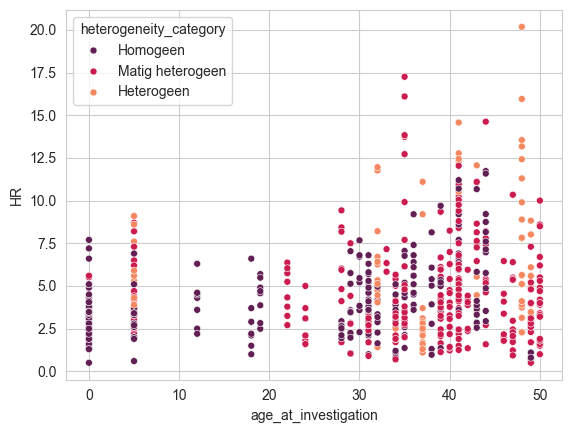

In [65]:
#HR vs leeftijd
plt.figure()
sns.scatterplot(data=df_final, x = 'age_at_investigation', y = 'HR', hue = 'heterogeneity_category', palette='rocket', hue_order=hue_order, s=25)

<Axes: xlabel='HR_mean', ylabel='sig_b_std'>

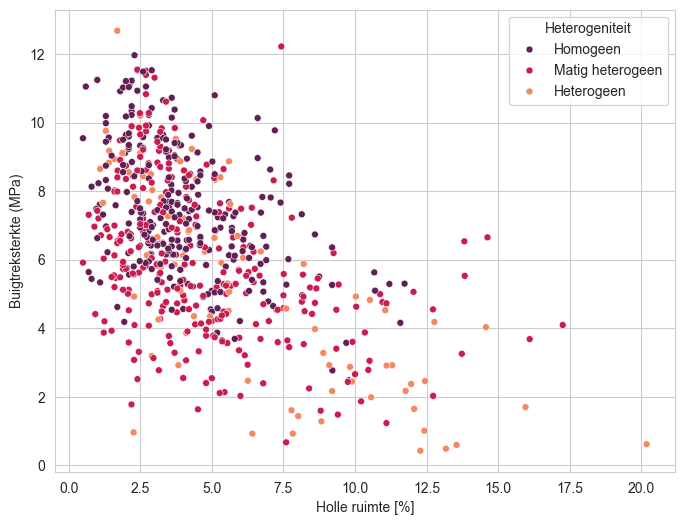

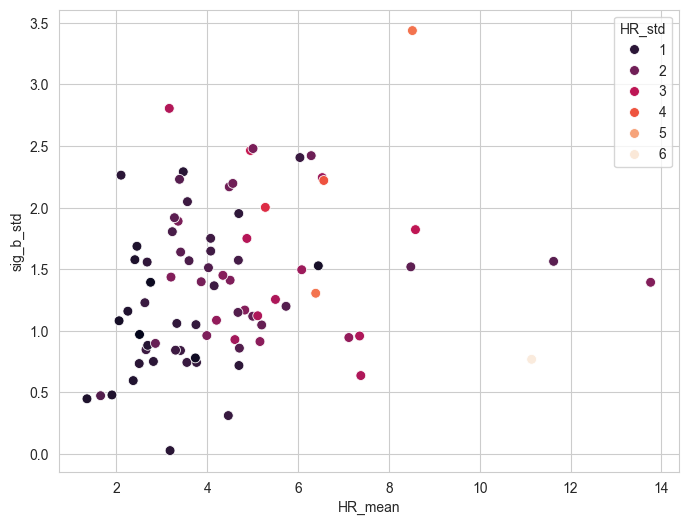

In [66]:
#plot buigtreksterkte in relatie tot HR
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_final, x = 'HR', y = 'sig_b', hue = 'heterogeneity_category', palette='rocket', hue_order=hue_order, s=25, ax=ax)
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_xlabel('Holle ruimte [%]')

ax.legend(title = 'Heterogeniteit')

fig,ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=data_per_dike_project_original, x='HR_mean', y='sig_b_std', hue='HR_std', palette='rocket', hue_order=hue_order, s=50, ax=ax)

# Analyses

## Filtering van de data/uitsluiten

### Impact uitsluiten van HR > 9%: welke punten verdwijnen?

Text(0.5, 0, 'Leeftijd (jaar)')

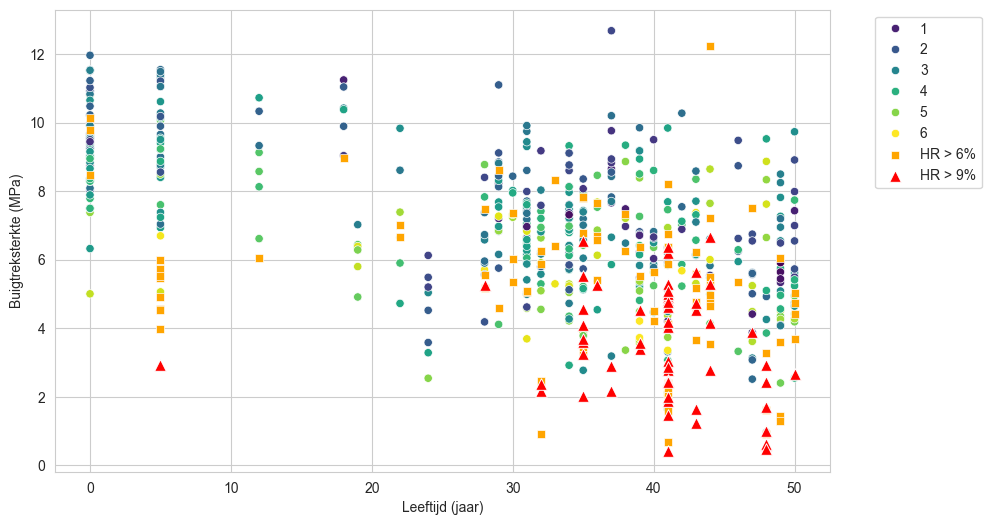

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
threshold_hr = [6, 9]
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] <= threshold_hr[0]], x='age_at_investigation', y='sig_b', hue='HR',palette='viridis')
sns.scatterplot(ax=ax, data=df_final.loc[(df_final['HR'] >= threshold_hr[0]) & (df_final['HR'] < threshold_hr[1])], x='age_at_investigation', y='sig_b', color= 'orange', marker='s', label = 'HR > 6%')
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] > threshold_hr[1]], x='age_at_investigation', y='sig_b', color= 'red', marker='^', label = 'HR > 9%', s=70)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.ylabel('Buigtreksterkte (MPa)')
plt.xlabel('Leeftijd (jaar)')

(0.0, 17.5)

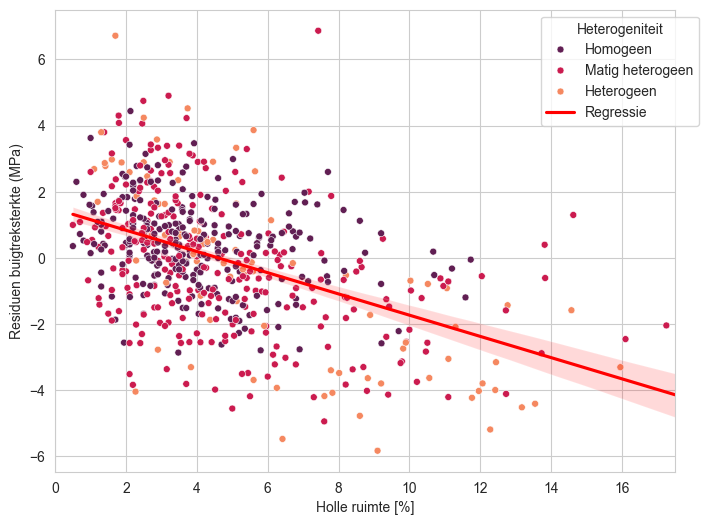

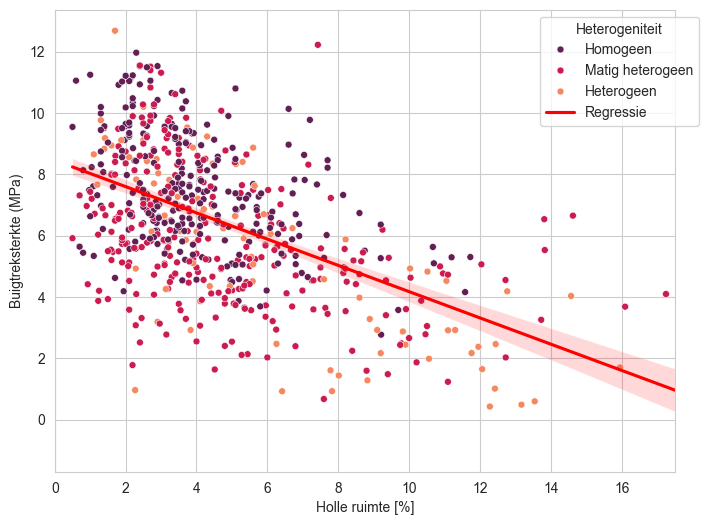

In [78]:
#relatie tussen HR en en residuen
fig,ax = plt.subplots(figsize=(8,6))
sns.scatterplot(ax=ax, data=df_final, x='HR', y='resid_all', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=25)
sns.regplot(ax=ax, data=df_final, x='HR', y='resid_all', scatter=False, color='red', label = 'Regressie')

ax.set_ylabel('Residuen buigtreksterkte (MPa)')
ax.set_xlabel('Holle ruimte [%]')
#legend
h, l = ax.get_legend_handles_labels()

ax.legend(h, l, title='Heterogeniteit', bbox_to_anchor=(1.05, 1))
ax.set_xlim(0, 17.5)

#relatie tussen HR en en residuen
fig,ax = plt.subplots(figsize=(8,6))
sns.scatterplot(ax=ax, data=df_final, x='HR', y='sig_b', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=25)
sns.regplot(ax=ax, data=df_final, x='HR', y='sig_b', scatter=False, color='red', label = 'Regressie')

ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_xlabel('Holle ruimte [%]')
#legend
h, l = ax.get_legend_handles_labels()

ax.legend(h, l, title='Heterogeniteit', bbox_to_anchor=(1.05, 1))
ax.set_xlim(0, 17.5)

<Axes: xlabel='count_V_Ber_below_010', ylabel='sig_b_std'>

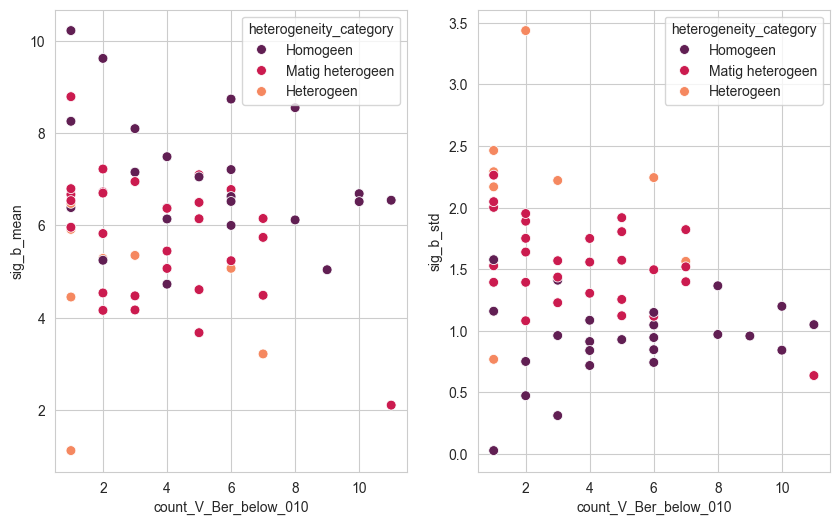

In [90]:
#drop all columns with 'count_hr_above_9' from data_per_dike_project
data_per_dike_project = data_per_dike_project.loc[:, ~data_per_dike_project.columns.str.contains('count_hr_above_9')]
#in df_final make a groupby where we count the number of boreholes per project_dike_id that have HR > 9%
count_hr_above_9 = df_final[df_final['HR'] > 9].groupby('project_dike_id').size()
count_V_Ber_below_010 = df_final[df_final['V_Ber'] < 0.10].groupby('project_dike_id').size()
#join to data_per_dike_project
data_per_dike_project = data_per_dike_project.join(count_hr_above_9.rename('count_hr_above_9'), on='project_dike_id')
data_per_dike_project = data_per_dike_project.join(count_V_Ber_below_010.rename('count_V_Ber_below_010'), on='project_dike_id')
data_per_dike_project.head()

#plot mean sig_b vs count_hr_above_9 and std
fig,ax = plt.subplots(figsize=(10,6), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='count_V_Ber_below_010', y='sig_b_mean', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=50, ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='count_V_Ber_below_010', y='sig_b_std', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=50, ax=ax[1])

### Heterogeniteit

(-0.5, 70.0)

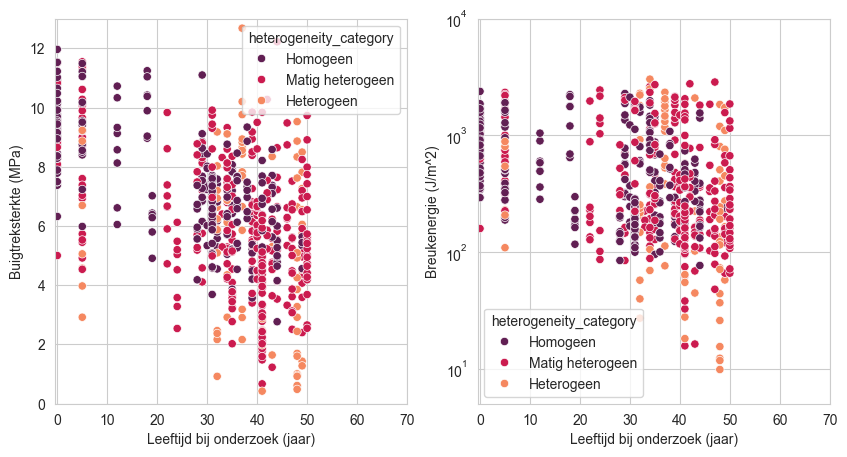

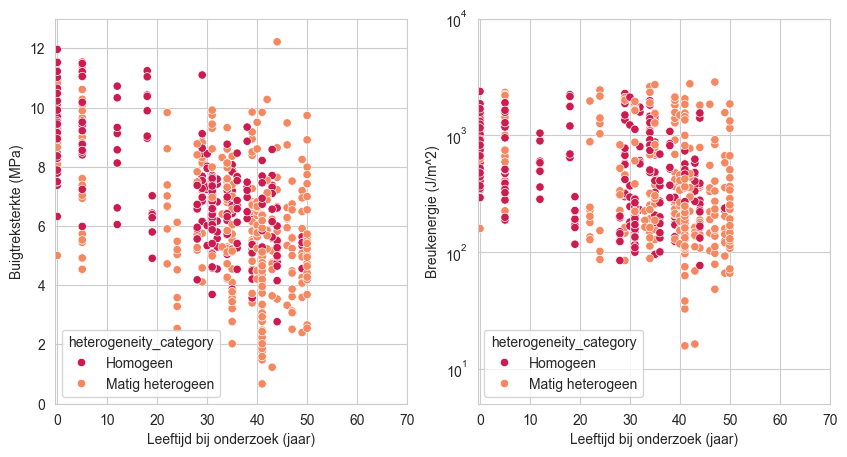

In [91]:
hue_order = ['Homogeen', 'Matig heterogeen', 'Heterogeen']
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='heterogeneity_category', hue_order=hue_order, palette='rocket', ax=ax[0])
sns.scatterplot(data=df_final, x='age_at_investigation', y='G_c', hue='heterogeneity_category', hue_order=hue_order, palette='rocket', ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[0].set_ylim(0, 13)
ax[1].set_ylim(5, 10000)
ax[0].set_xlim(-0.5, 70)
ax[1].set_xlim(-0.5, 70)
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Heterogeen'], x='age_at_investigation', y='sig_b', hue='heterogeneity_category', hue_order=hue_order[0:2], palette=sns.color_palette('rocket',n_colors=3)[1:], ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Heterogeen'], x='age_at_investigation', y='G_c', hue='heterogeneity_category', hue_order=hue_order[0:2], palette=sns.color_palette('rocket',n_colors=3)[1:], ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[0].set_ylim(0, 13)
ax[1].set_ylim(5, 10000)
ax[0].set_xlim(-0.5, 70)
ax[1].set_xlim(-0.5, 70)

In [92]:
data_per_dike_project.loc[data_per_dike_project.investigation_year == 2024][['dike_name','sig_b_mean','sig_b_cov', 'HR_mean','age_at_investigation']]

,dike_name,sig_b_mean,sig_b_cov,HR_mean,age_at_investigation
73,proefvakken_pov-wadden_-_vak_1_(harlingen)_-,6.216620,0.389579,6.287500,5.0
74,proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_...,8.311080,0.264267,4.562500,5.0
75,proefvakken_pov-wadden_-_vak_4_(westhoek)_top_...,9.456263,0.235793,3.387500,5.0
76,"proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4...",7.193846,0.201546,4.342857,5.0
77,"proefvakken_pov-wadden_-_vak_6_(westhoek)_17,6...",8.554009,0.159555,4.150000,5.0
78,"proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8...",10.225289,0.113277,2.250000,5.0


Text(0.5, 0, 'Leeftijd bij onderzoek (jaar)')

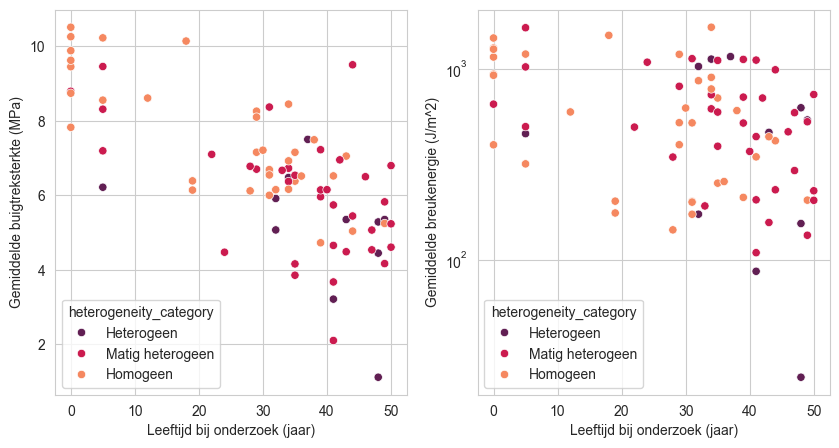

In [93]:
#same but for data_per_dike_project
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], palette='rocket', ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_mean', hue='heterogeneity_category', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], palette='rocket', ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Gemiddelde buigtreksterkte (MPa)')
ax[1].set_ylabel('Gemiddelde breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')

Text(0, 0.5, '')

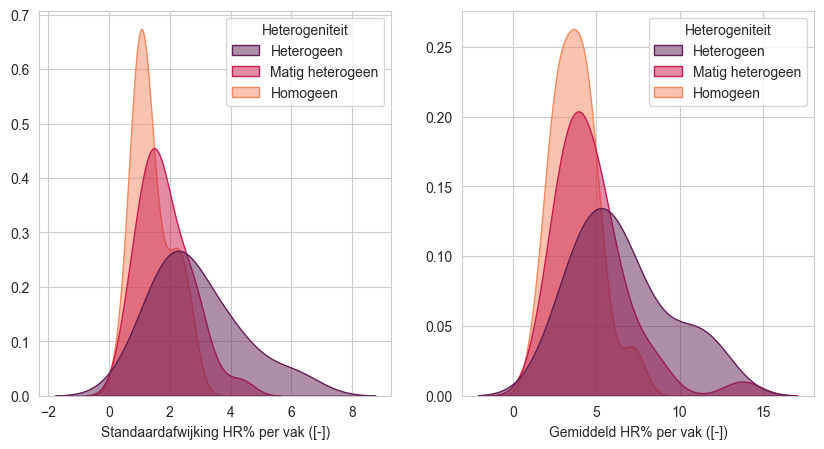

In [94]:
#density plot van heterogeniteitscategorie (als hue) met HR_std voor secties
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.kdeplot(data=data_per_dike_project.rename(columns={'heterogeneity_category' : 'Heterogeniteit'}), x='HR_std', hue='Heterogeniteit', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], fill=True, common_norm=False, palette='rocket', alpha=0.5, ax=ax[0])
sns.kdeplot(data=data_per_dike_project.rename(columns={'heterogeneity_category' : 'Heterogeniteit'}), x='HR_mean', hue='Heterogeniteit', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], fill=True, common_norm=False, palette='rocket', alpha=0.5, ax=ax[1])
ax[0].set_xlabel('Standaardafwijking HR% per vak ([-])')
ax[1].set_xlabel('Gemiddeld HR% per vak ([-])')
ax[0].set_ylabel('')
ax[1].set_ylabel('')
#rename legend title but keep the rest of the legend the same
# ax[0].legend(handles=ax[0].get_legend_handles_labels()[0], labels=ax[0].get_legend_handles_labels()[1], title='Heterogeniteitscategorie')
# ax[1].legend(handles=ax[1].get_legend_handles_labels()[0], labels=ax[1].get_legend_handles_labels()[1], title='Heterogeniteitscategorie')

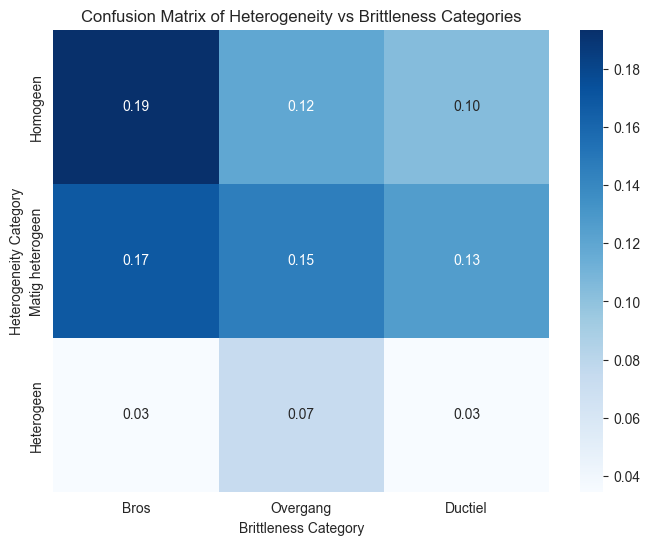

In [95]:
#check how often heterogeneity categories correspond to brittleness categories
df_final.groupby(['heterogeneity_category', 'brittleness']).size().unstack(fill_value=0)
#make a confusion matrix heatmap of the above
confusion_matrix = df_final.groupby(['heterogeneity_category', 'brittleness']).size().unstack(fill_value=0)
plt.figure(figsize=(8,6))
#ensure sequence of x is bros, overgang, ductiel and y is Homogeen, Matig heterogeen, Heterogeen. Normalize all values to sum to 1 in total
confusion_matrix = confusion_matrix.reindex(columns=['bros', 'overgang', 'ductiel'], index=['Homogeen', 'Matig heterogeen', 'Heterogeen'])
confusion_matrix = confusion_matrix.div(confusion_matrix.sum().sum(), axis=0)
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Bros', 'Overgang', 'Ductiel'], yticklabels=['Homogeen', 'Matig heterogeen', 'Heterogeen'])
plt.xlabel('Brittleness Category')
plt.ylabel('Heterogeneity Category')
plt.title('Confusion Matrix of Heterogeneity vs Brittleness Categories')
plt.show()

## Construction year

Text(0, 0.5, 'Bitumen gehalte (%)  ')

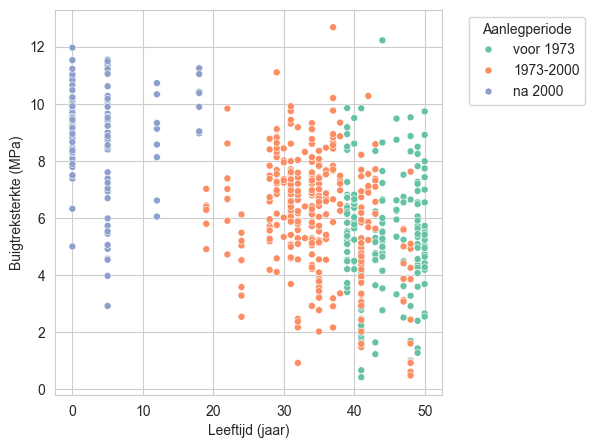

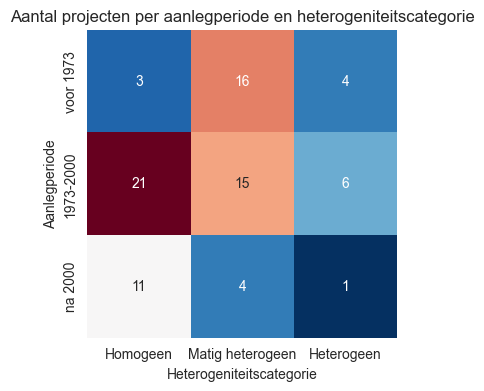

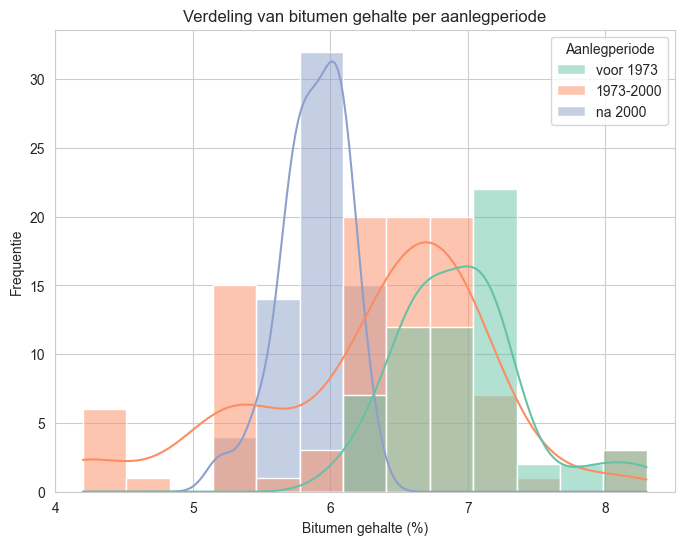

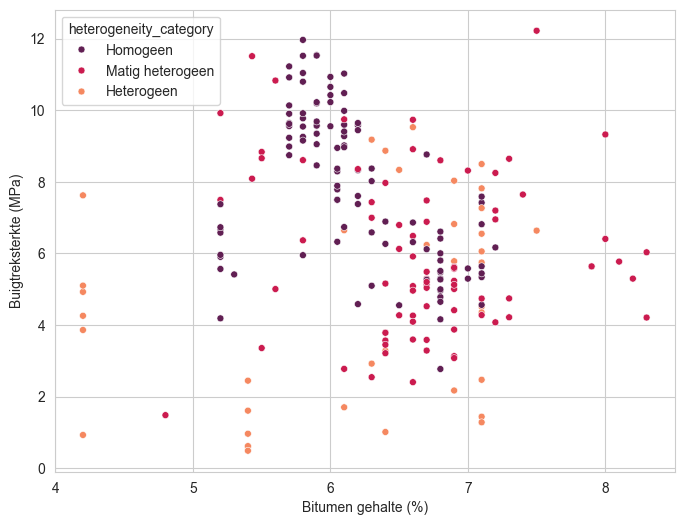

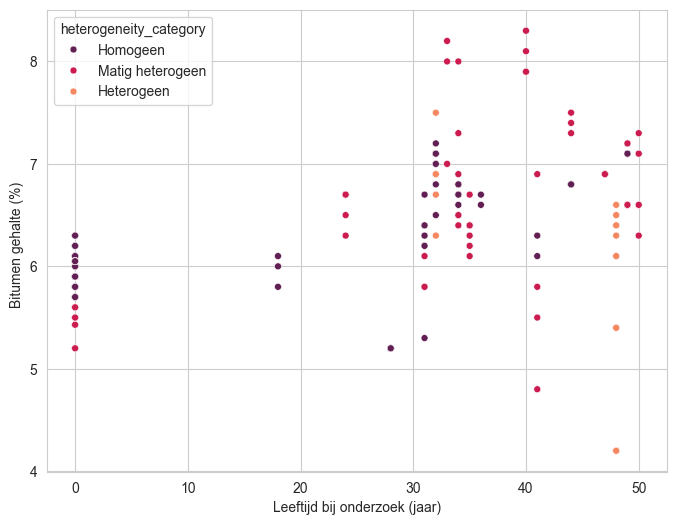

In [136]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='construction_year_category', ax=ax, s=25, palette='Set2')

#make a confusion plot for construction year category vs heterogeneity category
confusion_matrix = data_per_dike_project.groupby(['construction_year_category', 'heterogeneity_category']).size().unstack(fill_value=0)
#ensure sequence of x is Homogeen, Matig heterogeen, Heterogeen and y is before 1973, 1973-2000, after 2000
confusion_matrix = confusion_matrix.reindex(columns=['Homogeen', 'Matig heterogeen', 'Heterogeen'], index=['voor 1973', '1973-2000', 'na 2000'])
#normalize all values to sum to 1 in total
# confusion_matrix = confusion_matrix.div(confusion_matrix.sum().sum(), axis=0)
#legend
h, l = plt.gca().get_legend_handles_labels()
ax.legend(h, l, title='Aanlegperiode', bbox_to_anchor=(1.05, 1))
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_xlabel('Leeftijd (jaar)')

fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(confusion_matrix, annot=True, fmt=".0f", cmap='RdBu_r', cbar=False)
ax.set_xlabel('Heterogeniteitscategorie')
ax.set_ylabel('Aanlegperiode')
ax.set_title('Aantal projecten per aanlegperiode en heterogeniteitscategorie')

#histplot of bitumen content per construction year category
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(data=df_final.rename(columns={'construction_year_category': 'Aanlegperiode'}), x='bitumen', hue='Aanlegperiode', palette='Set2', kde=True, ax=ax)
ax.set_xlabel('Bitumen gehalte (%)')
ax.set_ylabel('Frequentie')
ax.set_title('Verdeling van bitumen gehalte per aanlegperiode')

#relatie bitumen buigtreksterkte
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_final, x='bitumen', y='sig_b', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=25, ax=ax)
ax.set_xlabel('Bitumen gehalte (%)')
ax.set_ylabel('Buigtreksterkte (MPa)')

#relatie bitumen tijd
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_final, x='age_at_investigation', y='bitumen', hue='heterogeneity_category', palette='rocket', hue_order=hue_order, s=25, ax=ax)
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
ax.set_ylabel('Bitumen gehalte (%)  ')



In [132]:
l

[]

## Pooling

### Algemeen

Eerst kijken naar de correlaties in de data

Text(0.5, 1.0, 'Correlation Matrix of Mean Values per Dike Project')

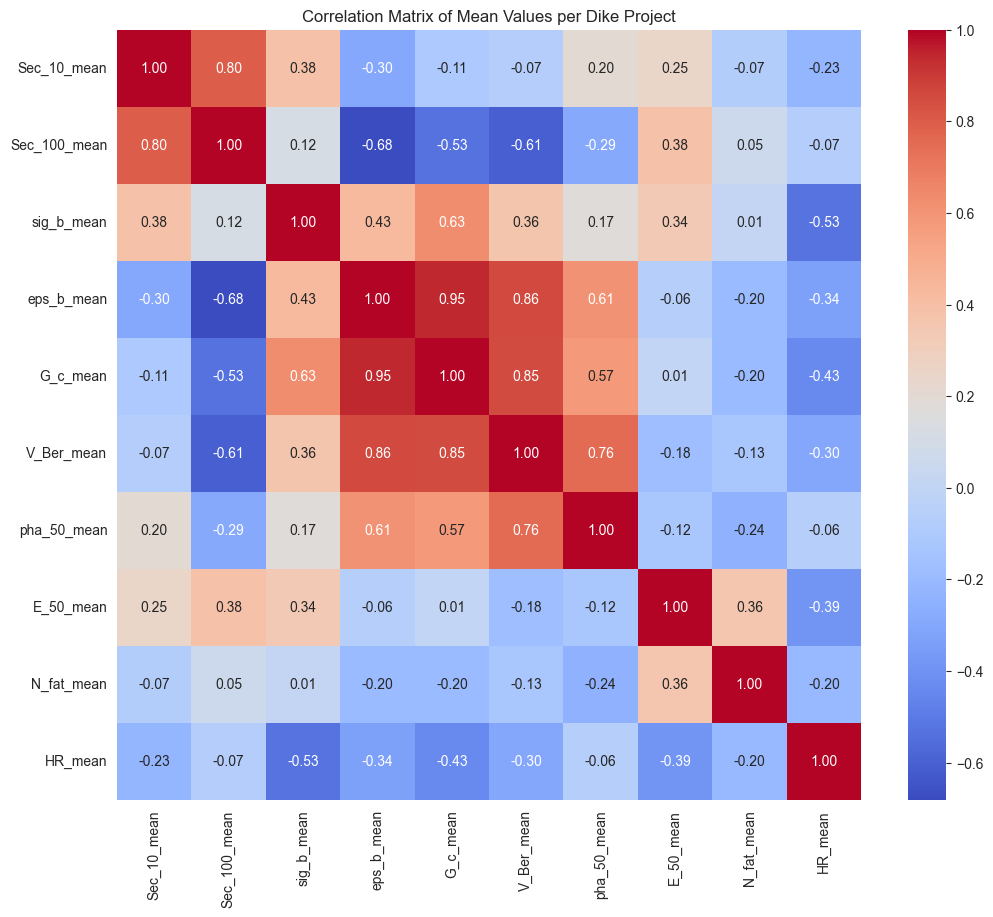

In [97]:
# correlaties bij data_per_dike_project
data_per_dike_project[['Sec_10_mean', 'Sec_100_mean', 'sig_b_mean', 'eps_b_mean', 'G_c_mean', 'V_Ber_mean', 'pha_50_mean', 'E_50_mean', 'N_fat_mean', 'HR_mean']].corr()
#heatmaps of the correlations
plt.figure(figsize=(12,10))

sns.heatmap(data_per_dike_project[['Sec_10_mean', 'Sec_100_mean', 'sig_b_mean', 'eps_b_mean', 'G_c_mean','V_Ber_mean', 'pha_50_mean', 'E_50_mean', 'N_fat_mean', 'HR_mean']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Mean Values per Dike Project')


{'Lagrange multiplier statistic': np.float64(6.020061552588656), 'p-value': np.float64(0.014144153407377773), 'f-value': np.float64(6.058355518139578), 'f p-value': np.float64(0.014105049951914769)}
{'Lagrange multiplier statistic': np.float64(3.3583219516657854), 'p-value': np.float64(0.0668661715325548), 'f-value': np.float64(3.3667129242713028), 'f p-value': np.float64(0.06707122546939469)}


<Axes: xlabel='age_at_investigation'>

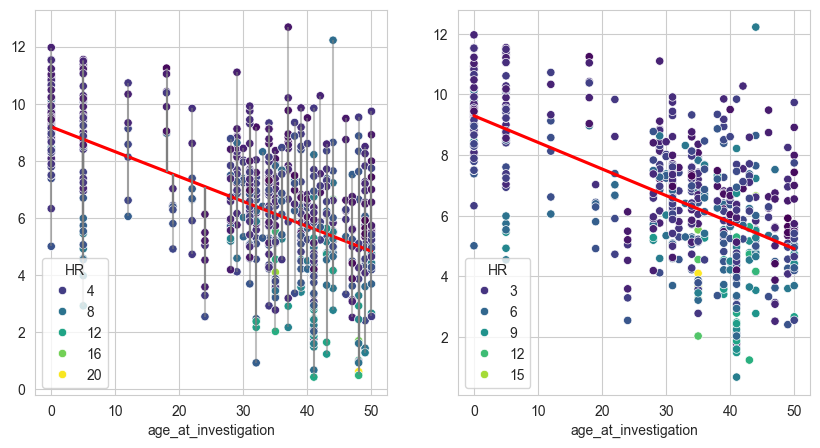

In [98]:
#Breusch-Pagan Lagrange Multiplier test for heteroscedasticity
from xml.parsers.expat import model
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

#run on df_final
X = df_final[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_final['sig_b']
model1 = sm.OLS(y, X).fit()
bp_test = het_breuschpagan(model1.resid, model1.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

#run on df_final but without heterogeneneity category 'Heterogeen'
df_final_sub = df_final[df_final['heterogeneity_category'] != 'Heterogeen']
X = df_final_sub[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_final_sub['sig_b']
model2 = sm.OLS(y, X).fit()
bp_test = het_breuschpagan(model2.resid, model2.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

#plot both models and the data
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis', ax=ax[0])
#add regression line from model1
sns.regplot(x=df_final['age_at_investigation'], y=model1.fittedvalues, scatter=False, ax=ax[0], color='red', label='Regression Line')
#show residuals as vertical lines
for i in range(len(df_final)):
    ax[0].vlines(x=df_final['age_at_investigation'].iloc[i], ymin=model1.fittedvalues.iloc[i], ymax=df_final['sig_b'].iloc[i], color='gray', alpha=0.5)

#same for model2
sns.scatterplot(data=df_final_sub, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis', ax=ax[1])
#add regression line from model2
sns.regplot(x=df_final_sub['age_at_investigation'], y=model2.fittedvalues, scatter=False, ax=ax[1], color='red', label='Regression Line')

Text(0.5, 1.0, 'Correlation Matrix of Coefficient of Variation per Dike Project')

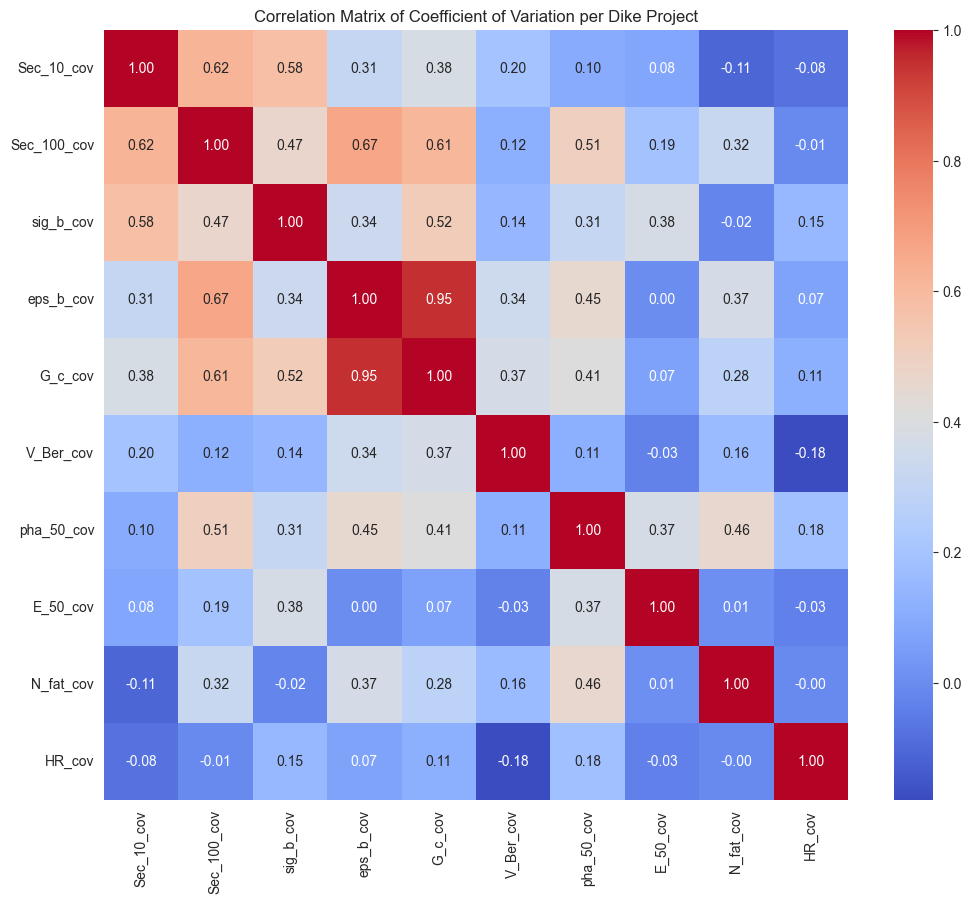

In [99]:
#zelfde voor CoV
data_per_dike_project[['Sec_10_cov', 'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov', 'V_Ber_cov', 'pha_50_cov', 'E_50_cov', 'N_fat_cov', 'HR_cov']].corr()
#heatmaps of the correlations
plt.figure(figsize=(12,10))
sns.heatmap(data_per_dike_project[['Sec_10_cov', 'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov', 'V_Ber_cov', 'pha_50_cov', 'E_50_cov', 'N_fat_cov', 'HR_cov']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Coefficient of Variation per Dike Project')

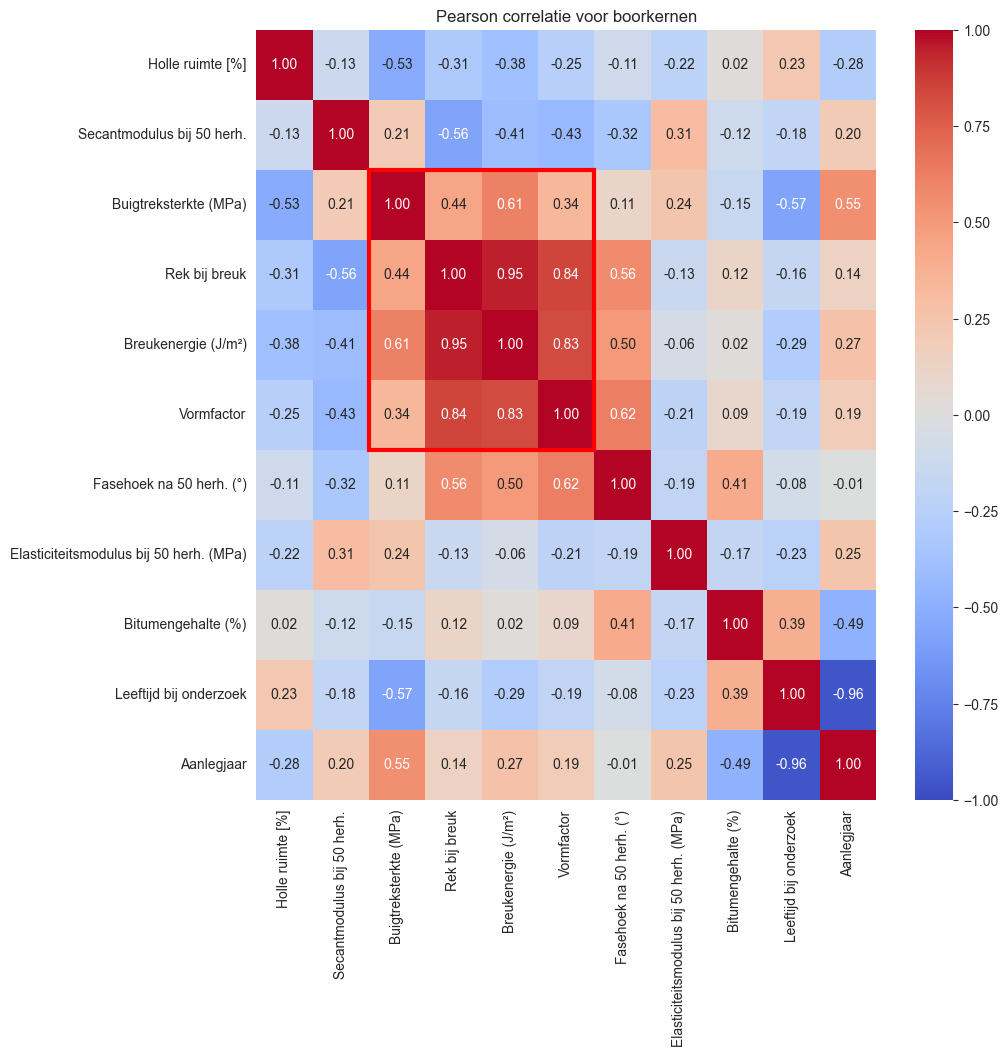

In [120]:
#compute correlation matrix of df_final for columns 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'age_at_investigation'
#copy dataframe 
df_final_copy = df_final.copy()
#get subset
df_final_copy = df_final_copy[['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'bitumen', 'age_at_investigation', 'construction_year']]
#rename the columns to more meaningful names
df_final_copy = df_final_copy.rename(columns={'HR':'Holle ruimte [%]', 'Sec_50':'Secantmodulus bij 50 herh.', 'sig_b':'Buigtreksterkte (MPa)', 'eps_b':'Rek bij breuk', 'G_c':'Breukenergie (J/m²)', 'V_Ber':'Vormfactor', 'pha_50':'Fasehoek na 50 herh. (°)', 'E_50':'Elasticiteitsmodulus bij 50 herh. (MPa)', 'bitumen': 'Bitumengehalte (%)', 'age_at_investigation':'Leeftijd bij onderzoek', 'construction_year':'Aanlegjaar'})

correlation_matrix_pearson = df_final_copy.corr('pearson')
# correlation_matrix_spearman = df_final[['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('kendall')
#plot correlation matrix as heatmap
fig, ax = plt.subplots(figsize=(10,10),)
sns.heatmap(correlation_matrix_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
# sns.heatmap(correlation_matrix_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax.set_title('Pearson correlatie voor boorkernen')

#make red box around Buigtreksterkte, Rek bij breuk, breukenergie and vormfactor
ax.add_patch(plt.Rectangle((2,2),4,4,fill=False,edgecolor='red',lw=3))


Text(0.5, 1.0, 'Homogeen')

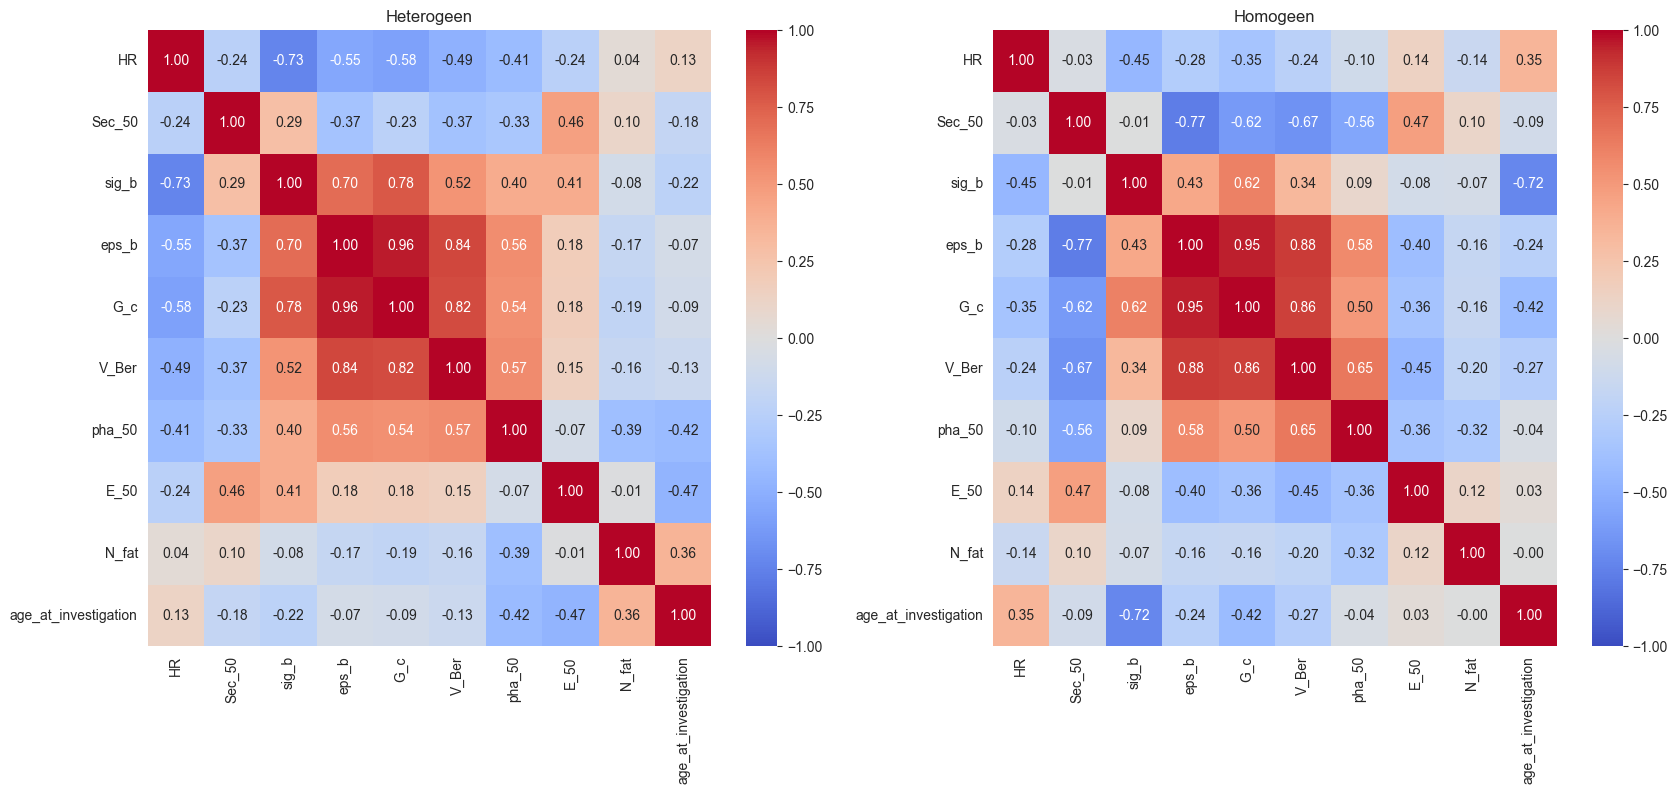

In [101]:
correlation_matrix_pearson_heterogeen = df_final.loc[df_final.heterogeneity_category == 'Heterogeen'][['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
correlation_matrix_pearson_homogeen = df_final.loc[df_final.heterogeneity_category == 'Homogeen'][['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
#plot both as heatmaps side by side
fig, ax = plt.subplots(figsize=(20,8), ncols=2)
sns.heatmap(correlation_matrix_pearson_heterogeen, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax[0])
sns.heatmap(correlation_matrix_pearson_homogeen, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax[1])
ax[0].set_title('Heterogeen')
ax[1].set_title('Homogeen')

### bros versus ductiel


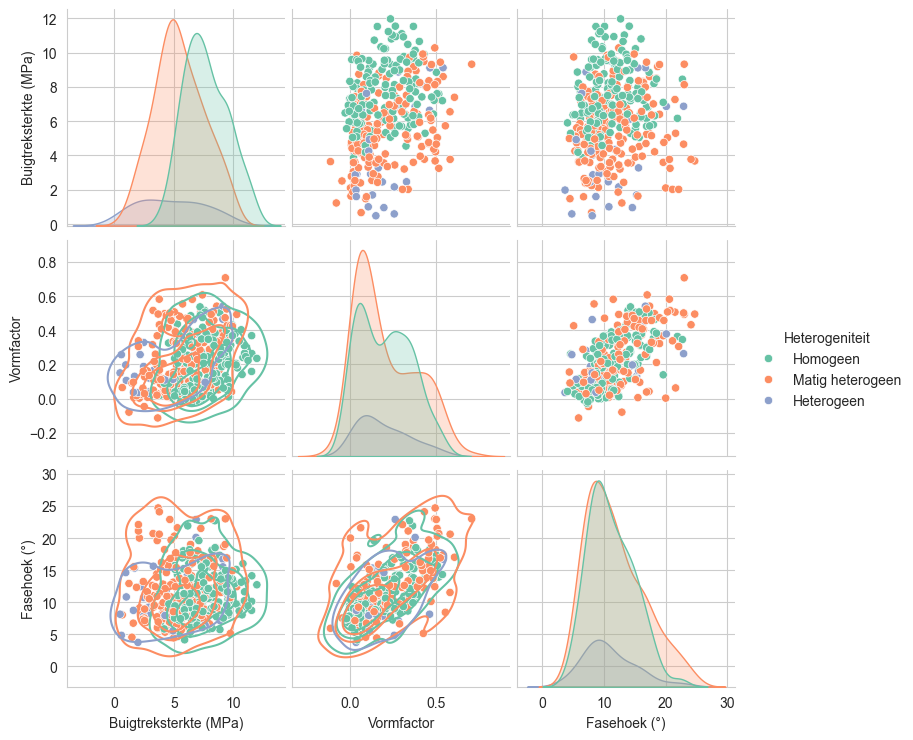

In [109]:
#pairplot of df_final with columns sig_b, V_Ber, pha_ini
g = sns.pairplot(df_final.loc[df_final.pha_ini < 1e6], vars=['sig_b', 'V_Ber', 'pha_50'], hue='heterogeneity_category', palette='Set2',hue_order=hue_order, diag_kind='kde')
g.map_lower(sns.kdeplot, levels=4, color=".2")
#change y-labels to fasehoek, vormfactor en buigtreksterkte
g.axes[0,0].set_ylabel('Buigtreksterkte (MPa)')
g.axes[1,0].set_ylabel('Vormfactor')
g.axes[2,0].set_ylabel('Fasehoek (°)')
#same for xlabels
g.axes[2,0].set_xlabel('Buigtreksterkte (MPa)')
g.axes[2,1].set_xlabel('Vormfactor')
g.axes[2,2].set_xlabel('Fasehoek (°)')
#modify legend title
g._legend.set_title('Heterogeniteit')
plt.show()

### Regio

Text(0.5, 0, 'Leeftijd bij onderzoek (jaar)')

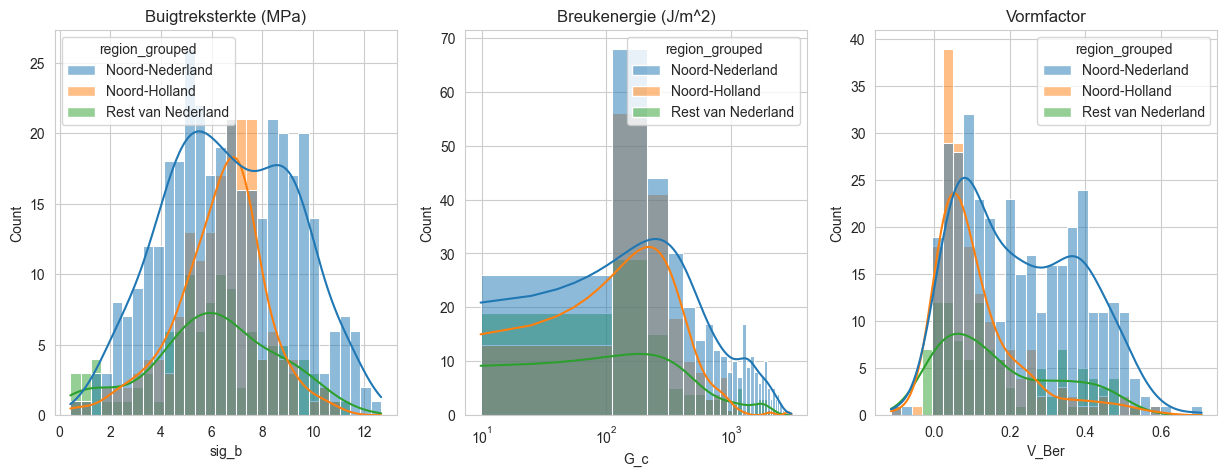

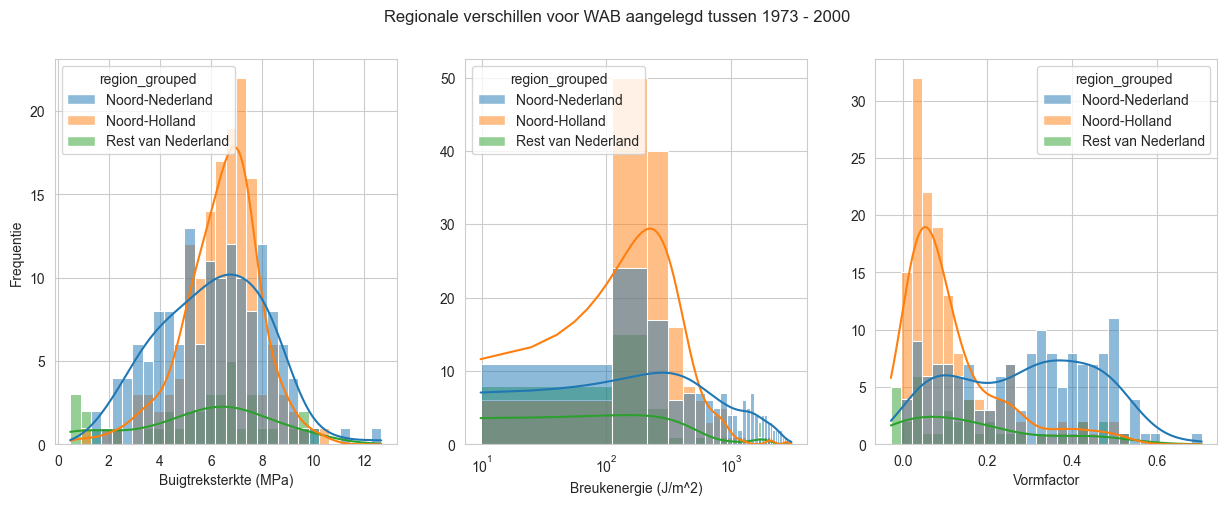

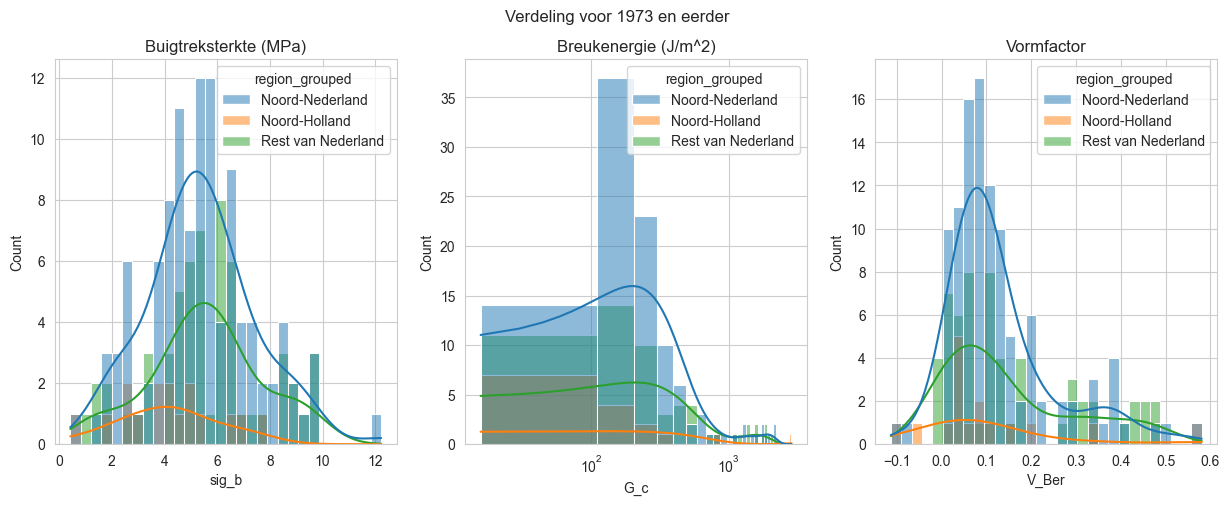

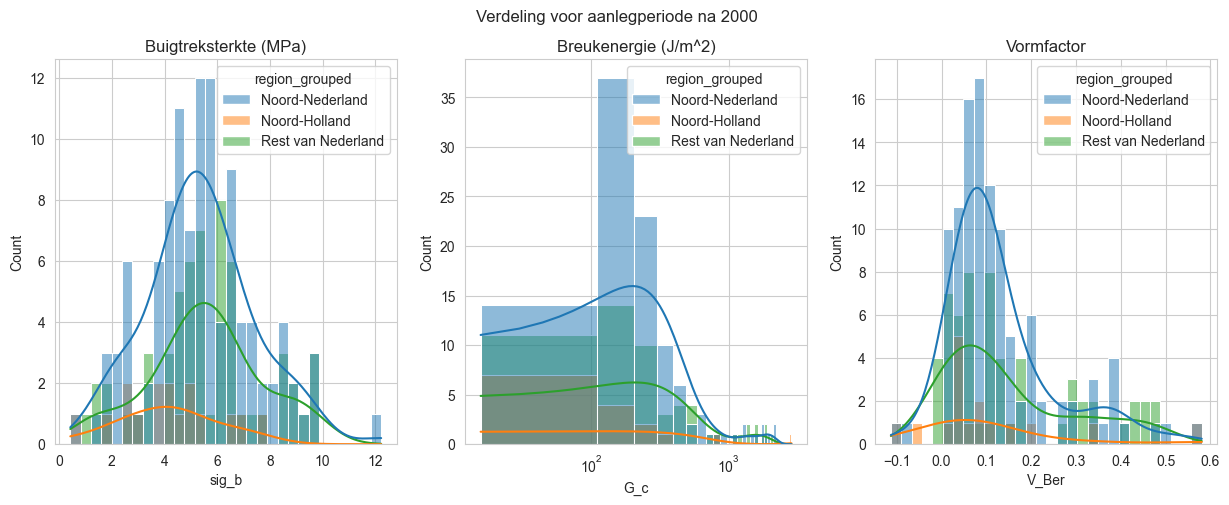

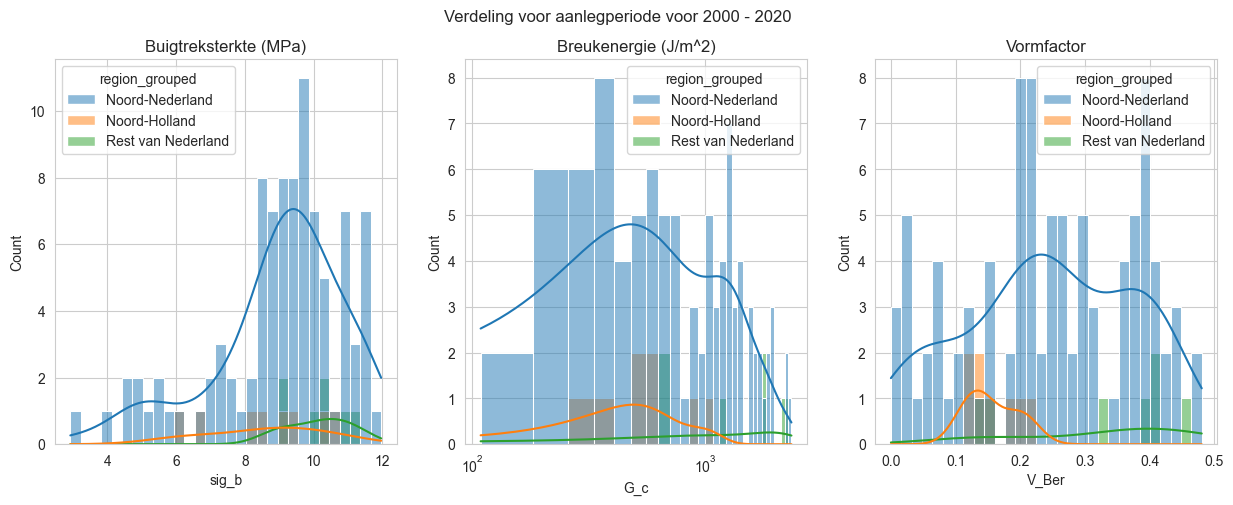

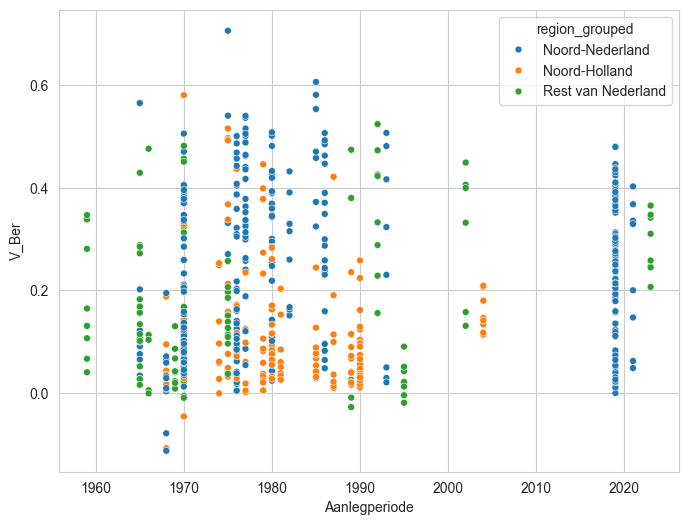

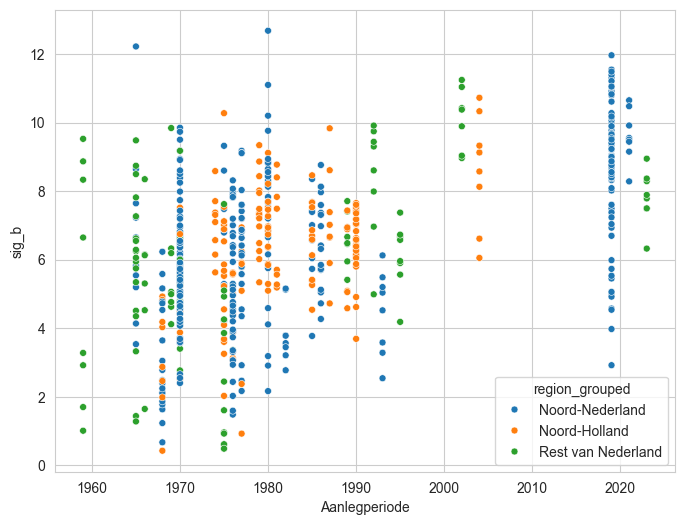

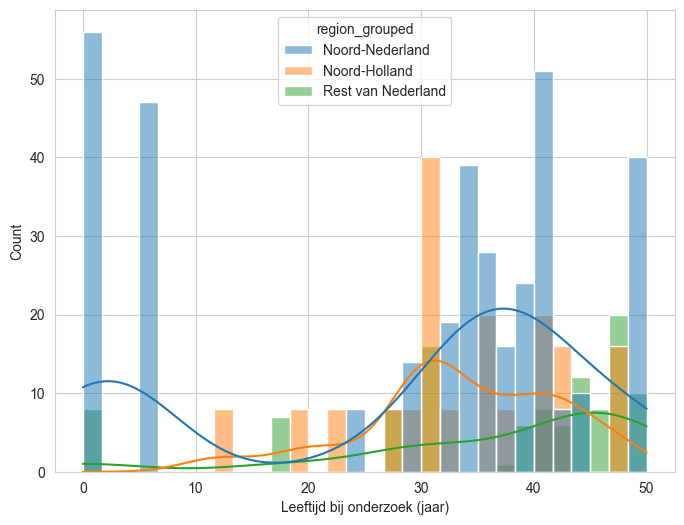

In [157]:
df_final['waterboard'].unique()
#translation dictionary to get consistent names:
region_dict = {'Hollandse Delta': 'Zuid Hollandse Delta',
 'Rijkswaterstaat Zuid-Holland Waterdistrict Haringvliet': 'Zuid Hollandse Delta',
'Wetterskip Fryslân': 'Friesland', 
'Noorderzijlvest': 'Groningen',
"{'emmapolder_47,5 - 57': 'Noorderzijlvest'}": 'Groningen',
"{'noorderhavendam_0 - 1,206': 'Wetterskip Fryslân'}": "Friesland",
"HHNK": "Noord-Holland",
'Waterschap Noorderzijlvest': "Groningen",
"{'zuidelijke_dijken_goeree_vak_1_42,525 - 43,04': 'Hollandse Delta'}": 'Zuid Hollandse Delta',
'PWN': "Noord-Holland", 'Groningen Seaports': "Groningen", 'Waterschap Scheldestromen': "Zeeland",
'Waterschap Hollandse Delta': "Zuid Hollandse Delta", 'Rijkswaterstaat': "Rijkswaterstaat",
'Havenbedrijf Rotterdam': "Zuid Hollandse Delta", 'Waterschap Zuiderzeeland': "Flevoland"}
df_final['region'] = df_final['waterboard'].map(region_dict)

#make a distinction of data where region is Groningen or Friesland vs Noord-Holland, vs rest of the Netherlands
df_final['region_grouped'] = df_final['region'].apply(lambda x: 'Noord-Nederland' if x in ['Groningen', 'Friesland'] else ('Noord-Holland' if x == 'Noord-Holland' else 'Rest van Nederland'))

plot_data = df_final#.loc[df_final.heterogeneity_category != 'Heterogeen']

jaargrenzen = [1973, 2000, 2020]

#plot the distributions for each region_grouped
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
ax[0].set_title('Buigtreksterkte (MPa)')
ax[1].set_title('Breukenergie (J/m^2)')
ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')

#plot the distributions for each region_grouped but only for construction year 
plot_data1 = plot_data.loc[(plot_data['construction_year'] >jaargrenzen[0]) & (plot_data['construction_year'] <=jaargrenzen[1])]
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data1, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data1, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data1, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
# ax[0].set_title('Buigtreksterkte (MPa)')
# ax[1].set_title('Breukenergie (J/m^2)')
# ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')
ax[0].set_ylabel('Frequentie')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[0].set_xlabel('Buigtreksterkte (MPa)')
ax[1].set_xlabel('Breukenergie (J/m^2)')
ax[2].set_xlabel('Vormfactor')
fig.suptitle(f'Regionale verschillen voor WAB aangelegd tussen {jaargrenzen[0]} - {jaargrenzen[1]}')

#plot the distributions for each region_grouped but only for construction year before 1973
plot_data1 = plot_data.loc[(plot_data['construction_year'] <=jaargrenzen[0])]
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data1, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data1, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data1, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
ax[0].set_title('Buigtreksterkte (MPa)')
ax[1].set_title('Breukenergie (J/m^2)')
ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')
fig.suptitle(f'Verdeling voor {jaargrenzen[0]} en eerder')

#plot the distributions for each region_grouped but only for construction year before 1973
plot_data2 = plot_data.loc[plot_data['construction_year'] < jaargrenzen[0]]
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data2, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data2, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data2, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
ax[0].set_title('Buigtreksterkte (MPa)')
ax[1].set_title('Breukenergie (J/m^2)')
ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')
fig.suptitle('Verdeling voor aanlegperiode na 2000')

#plot the distributions for each region_grouped but only for construction year between 1990 and 2010
plot_data2 = plot_data.loc[(plot_data['construction_year'] > jaargrenzen[1]) & (plot_data['construction_year'] <= jaargrenzen[2])]
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data2, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data2, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data2, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
ax[0].set_title('Buigtreksterkte (MPa)')
ax[1].set_title('Breukenergie (J/m^2)')
ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')
fig.suptitle(f'Verdeling voor aanlegperiode voor {jaargrenzen[1]} - {jaargrenzen[2]}')

fig, ax = plt.subplots(figsize=(8,6))
#scatterplot of construction_year vs V_Ber with hue region_grouped
sns.scatterplot(data=df_final, x='construction_year', y='V_Ber', hue='region_grouped', palette='tab10', hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'], s=25, ax=ax)
ax.set_xlabel('Aanlegperiode')

#same for sig_b
fig, ax = plt.subplots(figsize=(8,6))
#scatterplot of construction_year vs sig_b with hue region_grouped
sns.scatterplot(data=df_final, x='construction_year', y='sig_b', hue='region_grouped', palette='tab10', hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'], s=25, ax=ax)
ax.set_xlabel('Aanlegperiode')

#plot for age_at_investigation distribution with region_grouped as hue
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(data=df_final, x='age_at_investigation', hue='region_grouped', palette='tab10', hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'], kde=True, bins=30, ax=ax)
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')

In [35]:
#vervolganalyse brosheid
print(df_final.loc[df_final.V_Ber < 0.1].shape)

print(df_final.loc[df_final.pha_50 < 5].shape)

print(df_final.loc[(df_final.V_Ber < 0.1) & (df_final.pha_50 < 5)].shape)

(302, 46)
(17, 46)
(11, 46)


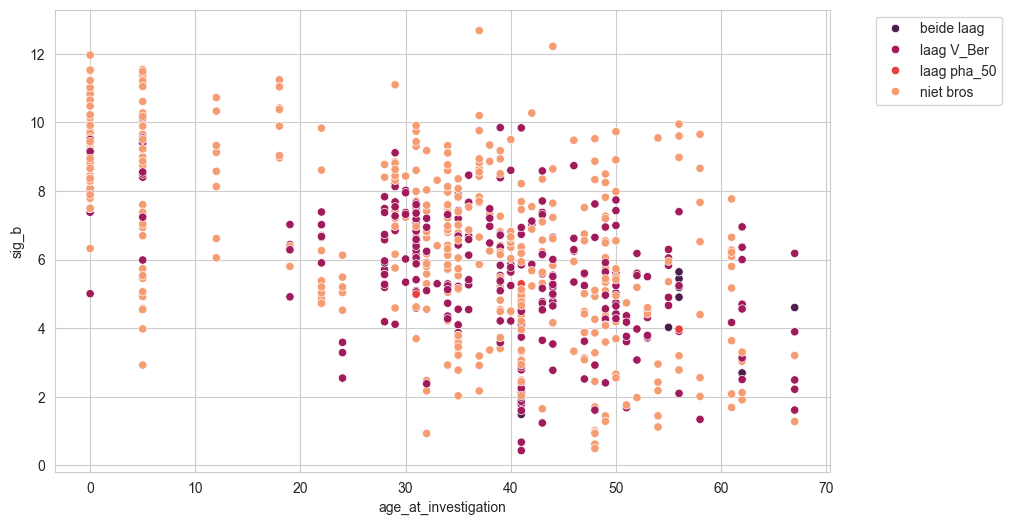

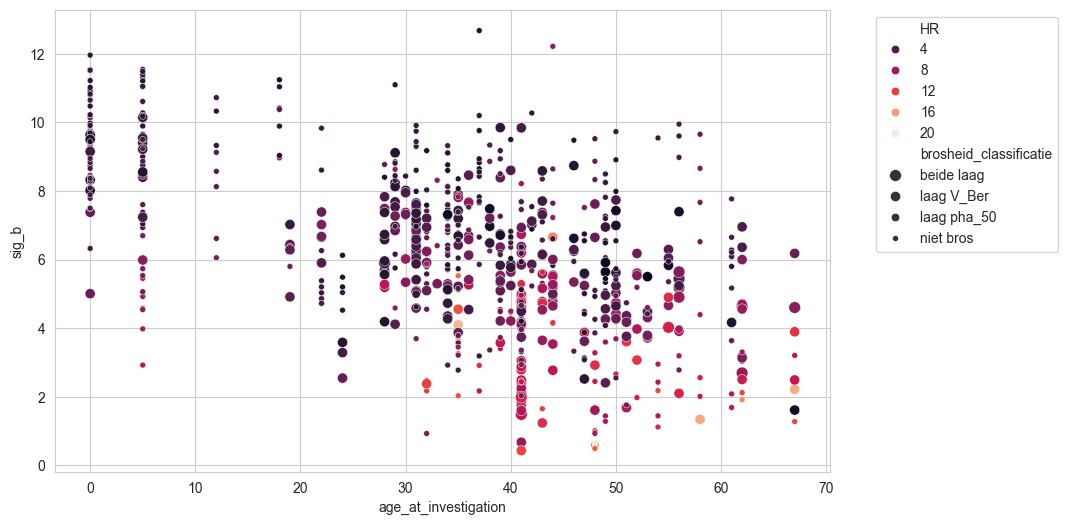

In [54]:
def bros_classifier(row):
    if (row['V_Ber'] < 0.1) and (row['pha_50'] < 5):
        return 'beide laag'
    elif (row['V_Ber'] < 0.1):
        return 'laag V_Ber'
    elif (row['pha_50'] < 5):
        return 'laag pha_50'
    else:
        return 'niet bros'
df_final['brosheid_classificatie'] = df_final.apply(bros_classifier, axis=1)

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='brosheid_classificatie',hue_order=['beide laag', 'laag V_Ber', 'laag pha_50', 'niet bros'], palette='rocket', ax=ax)
#regressielijnen toevoegen
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig,ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', size='brosheid_classificatie',size_order=['beide laag', 'laag V_Ber', 'laag pha_50', 'niet bros'], hue = 'HR', hue_norm=(0, 20), palette='rocket', ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

<Axes: xlabel='age_at_investigation', ylabel='pha_50_mean'>

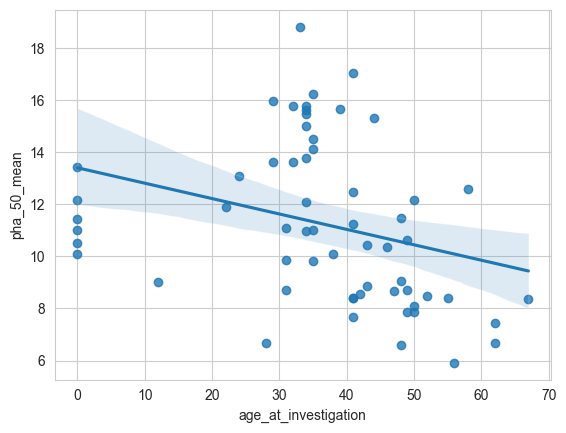

In [62]:
sns.regplot(data_per_dike_project, x='age_at_investigation', y='pha_50_mean')

In [60]:
data_per_dike_project.columns

Index(['borehole_id', 'project_dike_id', 'construction_year',
       'investigation_year', 'project_id', 'dike_id', 'project_name',
       'dike_name', 'waterboard', 'age_at_investigation', 'v_mean', 'v_std',
       'Sec_10_mean', 'Sec_10_std', 'Sec_50_mean', 'Sec_50_std',
       'Sec_100_mean', 'Sec_100_std', 'sig_b_mean', 'sig_b_std', 'eps_b_mean',
       'eps_b_std', 'G_c_mean', 'G_c_std', 'G_c_over_eps_b_mean',
       'G_c_over_eps_b_std', 'G_c_over_eps_b_sig_b_mean',
       'G_c_over_eps_b_sig_b_std', 'V_Ber_mean', 'V_Ber_std', 'pha_ini_mean',
       'pha_ini_std', 'pha_50_mean', 'pha_50_std', 'sig_cyc_mean',
       'sig_cyc_std', 'sig_perm_mean', 'sig_perm_std', 'E_ini_mean',
       'E_ini_std', 'E_50_mean', 'E_50_std', 'N_fat_mean', 'N_fat_std',
       'HR_mean', 'HR_std', 'HR_max', 'HR_min', 'bitumen_mean', 'bitumen_std',
       'number_of_boreholes_count', 'v_cov', 'Sec_10_cov', 'Sec_50_cov',
       'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov',
       'G_c_over_eps_b_cov